In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Tema 2 IA – Secțiunile 1 & 2
## Pipeline complet de antrenare + Monitorizare cu TensorBoard

Acest notebook acoperă:
- **Secțiunea 1**: Dataset, DataLoader, Model (MLP simplu), Loss, Optimizer, Bucla train/eval, Grafice
- **Secțiunea 2**: Monitorizarea antrenării cu TensorBoard

---

## 0. Instalare dependențe

In [ ]:
# Rulează o singură dată dacă nu ai pachetele instalate
# !pip install torch torchvision tensorboard scikit-learn matplotlib

## 1. Importuri și configurare globală

In [3]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from torch.utils.tensorboard import SummaryWriter
import torchvision

# ── Setăm device-ul ──────────────────────────────────────────────────────────
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Folosim device-ul: {device}")

# ── Seed global pentru reproductibilitate ────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

Folosim device-ul: cuda


## 1.1 Extragerea arhivelor din Google Drive

Pentru a utiliza seturile de date, le vom extrage din arhivele ZIP stocate în Google Drive.

In [7]:
import zipfile

# Define paths to zip files in Google Drive
CANDID_CAMERA_ZIP_PATH = 'drive/MyDrive/IA/Tema2/you-re-on-candid-camera.zip'
MOLES_ZIP_PATH = 'drive/MyDrive/IA/Tema2/vai-de-pielea-mea.zip'

# Define extraction directories
CANDID_CAMERA_EXTRACT_DIR = 'you-re-on-candid-camera/'
MOLES_EXTRACT_DIR = 'vai-de-pielea-mea/'

In [8]:
def extract_zip(zip_path, extract_dir):
    if not os.path.exists(extract_dir):
        print(f"Extracting {zip_path} to {extract_dir}...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_dir)
        print("Extraction complete.")
    else:
        print(f"Directory {extract_dir} already exists. Skipping extraction.")


In [9]:
# Extract 'you-re-on-candid-camera.zip'
extract_zip(CANDID_CAMERA_ZIP_PATH, CANDID_CAMERA_EXTRACT_DIR)

# Extract 'vai-de-pielea-mea.zip'
extract_zip(MOLES_ZIP_PATH, MOLES_EXTRACT_DIR)

Extracting drive/MyDrive/IA/Tema2/you-re-on-candid-camera.zip to you-re-on-candid-camera/...
Extraction complete.
Extracting drive/MyDrive/IA/Tema2/vai-de-pielea-mea.zip to vai-de-pielea-mea/...
Extraction complete.


## 2. Dataset și DataLoader

Definim un `Dataset` custom care funcționează cu structura de foldere a ambelor seturi de date din temă.
Structura așteptată pe disc:
```
data/
  train/
    clasa_0/  img1.jpg, img2.jpg ...
    clasa_1/  ...
  val/
    clasa_0/  ...
    clasa_1/  ...
```

> **Notă**: Dacă setul de date folosește fișiere CSV (cum e cazul 'You're on candid camera'),
> vezi varianta `ImageCSVDataset` de mai jos.

In [10]:
# ── Varianta 1: Dataset din structura de foldere ─────────────────────────────
class ImageFolderDataset(Dataset):
    """
    Dataset custom care parcurge un director cu subfoldere (câte unul per clasă).
    Exemplu structură:
        root_dir/
            akiec/  img1.jpg ...
            bcc/    ...
    """
    def __init__(self, root_dir, transform=None):
        self.samples = []
        self.transform = transform

        # Sortăm clasele pentru a fi determiniști
        classes = sorted(
            [d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))]
        )
        self.class_to_idx = {c: i for i, c in enumerate(classes)}
        self.idx_to_class = {i: c for c, i in self.class_to_idx.items()}

        for c in classes:
            cls_dir = os.path.join(root_dir, c)
            for fname in os.listdir(cls_dir):
                if fname.lower().endswith((".jpg", ".jpeg", ".png")):
                    self.samples.append((os.path.join(cls_dir, fname), self.class_to_idx[c]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")  # ne asigurăm că avem 3 canale
        if self.transform is not None:
            img = self.transform(img)
        return img, label

In [11]:
import csv

# ── Varianta 2: Dataset din fișier CSV ───────────────────────────────────────
# Folosit pentru setul de date "You're on candid camera" (splits/train.csv)
# Mapare pentru skin moles
MOLES_LABEL_MAP = {
    "akiec": 0,
    "bcc":   1,
    "bkl":   2,
    "df":    3,
    "mel":   4,
    "nv":    5,
    "vasc":  6,
}

class ImageCSVDataset(Dataset):
    def __init__(self, csv_path, root_dir="", transform=None, label_map=None):
        """
        label_map: dict opțional { "text_eticheta": int }
                   Dacă e None, se presupune că eticheta e deja int în CSV.
        """
        self.samples = []
        self.transform = transform

        with open(csv_path, newline="") as f:
            reader = csv.reader(f)
            next(reader, None)  # sărim header-ul
            for row in reader:
                rel_path, raw_label = row[0], row[1]

                # Convertim eticheta: text → int dacă avem label_map
                if label_map is not None:
                    label = label_map[raw_label.strip()]
                else:
                    label = int(raw_label)  # presupunem că e deja număr

                self.samples.append((os.path.join(root_dir, rel_path), label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform is not None:
            img = self.transform(img)
        return img, label

In [12]:
# ── Transformări ─────────────────────────────────────────────────────────────
# Transformări minimale (fără augmentare) — servesc ca baseline.
# Vom adăuga augmentare în Secțiunea 3 a temei.

# ─── Statistici pentru setul "Vai de pielea mea" (skin moles) ───
MOLES_MEAN = [0.7646, 0.5464, 0.5712]
MOLES_STD  = [0.1410, 0.1532, 0.1706]

# ─── Statistici pentru setul facial — le citim din JSON ────────
import json
norm_stats = json.load(open("you-re-on-candid-camera/splits/norm_stats.json"))
FACE_MEAN = norm_stats["mean"]
FACE_STD  = norm_stats["std"]
# Valori de rezervă (ImageNet) dacă nu avem JSON-ul:
# FACE_MEAN = [0.485, 0.456, 0.406]
# FACE_STD  = [0.229, 0.224, 0.225]

def make_transforms(mean, std, img_size=64):
    """Returnează un dict cu transform-uri pentru train și val/test."""
    # Pe train: nicio augmentare în Secțiunea 1 — adăugăm mai târziu
    train_tf = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std),
    ])
    # Pe val/test: NICIODATĂ augmentare
    val_tf = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std),
    ])
    return {"train": train_tf, "val": val_tf}

# Creăm transform-urile pentru skin moles
moles_tf = make_transforms(MOLES_MEAN, MOLES_STD, img_size=100)
# Creăm transform-urile pentru expresii faciale
face_tf  = make_transforms(FACE_MEAN, FACE_STD, img_size=100)

print("Transform-urile sunt gata.")

Transform-urile sunt gata.


In [13]:
# ── Crearea dataset-urilor și dataloaderelor ──────────────────────────────────
# Ajustează căile de mai jos la structura ta de directoare!

BATCH_SIZE = 64

# ─── Exemplu pentru skin moles ───────────────────────────────────────────────
# train_set = ImageFolderDataset("drive/myDrive/IA/Tema2/vai-de-pielea-mea", transform=moles_tf["train"])
# val_set   = ImageFolderDataset("data/moles/val",   transform=moles_tf["val"])

# ─── Exemplu pentru expresii faciale (CSV) ──────────────────────────────────
# Skin moles → label_map=MOLES_LABEL_MAP (etichete text)
train_set_moles = ImageCSVDataset(
    "vai-de-pielea-mea/train.csv",
    root_dir="vai-de-pielea-mea/train",
    transform=moles_tf["train"],   # ← moles_tf, nu face_tf!
    label_map=MOLES_LABEL_MAP,
)
val_set_moles = ImageCSVDataset(
    "vai-de-pielea-mea/test.csv",
    root_dir="vai-de-pielea-mea/test",
    transform=moles_tf["val"],
    label_map=MOLES_LABEL_MAP,
)

train_set_faces = ImageFolderDataset(
    "you-re-on-candid-camera/DATASET/train",
    transform=face_tf["train"],
    )

val_set_faces = ImageFolderDataset(
    "you-re-on-candid-camera/DATASET/test",
    transform=face_tf["val"],
    )




# ─── DataLoaders ─────────────────────────────────────────────────────────────
# IMPORTANT: drop_last=True previne erori la BatchNorm cu batch size=1
train_loader_moles = DataLoader(train_set_moles, batch_size=BATCH_SIZE,
                          shuffle=True, num_workers=2, drop_last=True)
val_loader_moles = DataLoader(val_set_moles,   batch_size=BATCH_SIZE,
                           shuffle=False, num_workers=2)

print(f"Train: {len(train_set_moles)} exemple, Val: {len(val_set_moles)} exemple")
print("Decomentează blocurile de mai sus după ce ai setul de date descărcat.")

Train: 6009 exemple, Val: 2003 exemple
Decomentează blocurile de mai sus după ce ai setul de date descărcat.


In [23]:
train_loader_faces = DataLoader(train_set_faces, batch_size=BATCH_SIZE,
                          shuffle=True, num_workers=2, drop_last=True)
val_loader_faces = DataLoader(val_set_faces,   batch_size=BATCH_SIZE,
                           shuffle=False, num_workers=2)

print(f"Train: {len(train_set_faces)} exemple, Val: {len(val_set_faces)} exemple")
print("Decomentează blocurile de mai sus după ce ai setul de date descărcat.")

Train: 12271 exemple, Val: 3068 exemple
Decomentează blocurile de mai sus după ce ai setul de date descărcat.


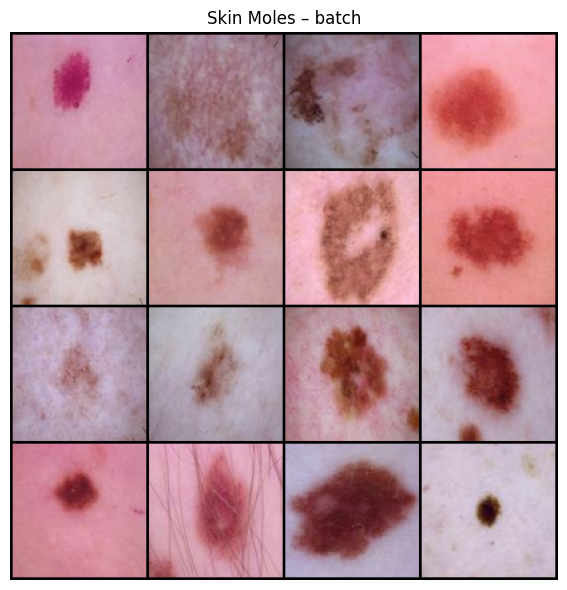

Etichete: [6, 5, 2, 5, 5, 5, 5, 5, 5, 2, 5, 4, 5, 5, 5, 5]
Decomentează show_batch după ce ai dataloader-ul creat.


In [24]:
# ── Vizualizare rapidă a unui batch ──────────────────────────────────────────
# Util pentru a verifica că imaginile arată corect după normalizare.

def show_batch(loader, mean, std, n=16, title="Batch"):
    """
    Afișează primele n imagini dintr-un batch, de-normalizate pentru vizualizare.
    """
    images, labels = next(iter(loader))
    images = images[:n]

    # De-normalizare pentru afișare
    mean_t = torch.tensor(mean).view(3, 1, 1)
    std_t  = torch.tensor(std).view(3, 1, 1)
    images_display = images * std_t + mean_t
    images_display = images_display.clamp(0, 1)

    grid = torchvision.utils.make_grid(images_display, nrow=4, padding=2)
    plt.figure(figsize=(10, 6))
    plt.imshow(grid.permute(1, 2, 0).numpy())
    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()
    print("Etichete:", labels[:n].tolist())

show_batch(train_loader_moles, MOLES_MEAN, MOLES_STD, title="Skin Moles – batch")
print("Decomentează show_batch după ce ai dataloader-ul creat.")

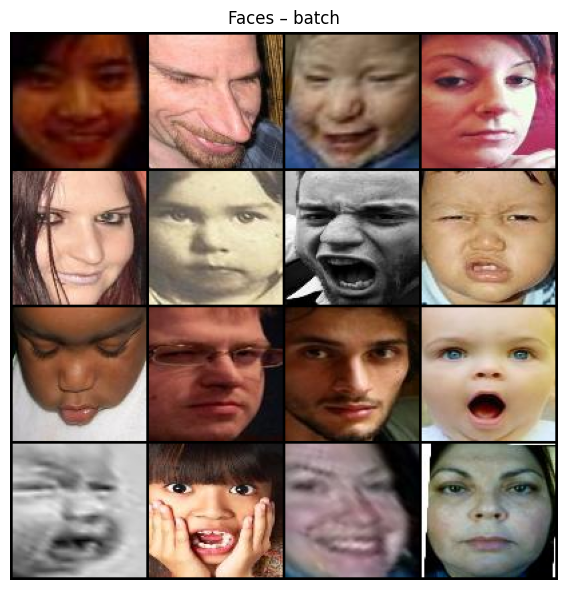

Etichete: [3, 3, 3, 6, 3, 6, 5, 2, 6, 2, 6, 0, 4, 0, 3, 6]


In [ ]:
show_batch(train_loader_faces, FACE_MEAN, FACE_STD, title="Faces – batch")

## 3. Modelul MLP

Un **MLP** (Multi-Layer Perceptron) aplatizează fiecare imagine într-un vector și o trece prin straturi liniare.

**De ce e suboptimal pentru imagini?** Nu exploatează structura spațială (vecini de pixeli), deci se saturează repede. Servește ca baseline față de CNN.

In [ ]:
class MLP(nn.Module):
    """
    MLP pentru clasificare imagini.
    Arhitectura:
      Flatten → Linear(input_dim, 512) → ReLU → Dropout(0.3)
             → Linear(512, num_classes)
    Args:
        input_channels: numărul de canale ale imaginii (3 pentru RGB)
        img_size: latura imaginii (presupunem pătrat: img_size x img_size)
        num_classes: numărul de clase
        use_dropout: dacă True, adaugă strat Dropout
    """
    def __init__(self, input_channels=3, img_height=130, img_width = 100, num_classes=7, use_dropout=True):
        super().__init__()
        input_dim = input_channels * img_height * img_width  # ex: 3*64*64 = 12288
        layers = [
            nn.Flatten(),
            nn.Linear(input_dim, 512),
            nn.ReLU(inplace=True),
        ]
        if use_dropout:
            layers.append(nn.Dropout(0.3))
        layers.append(nn.Linear(512, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


# ── Exemplu de instanțiere ───────────────────────────────────────────────────
# Ajustează num_classes la numărul de clase din setul tău de date:
#   7 pentru expresii faciale (Surprise, Fear, Disgust, ...)
#   7 pentru skin moles (akiec, bcc, bkl, df, mel, nv, vasc)

NUM_CLASSES = 7    # ← schimbă după nevoie
IMG_HEIGHT = 100  # ← schimbă dacă redimensionezi altfel
IMG_WIDTH = 100

device = "cuda" if torch.cuda.is_available() else "cpu"
model_moles = MLP(
    input_channels=3,
    img_height=IMG_HEIGHT,
    img_width=IMG_WIDTH,
    num_classes=NUM_CLASSES,
    use_dropout=True,   # setează False pentru ablația dropout
).to(device)

# Număr de parametri — util pentru compararea modelelor în raport
n_params = sum(p.numel() for p in model_moles.parameters() if p.requires_grad)
print(f"MLP – parametri antrenabili: {n_params:,}")
print(model_moles)

MLP – parametri antrenabili: 15,364,103
MLP(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=30000, out_features=512, bias=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=7, bias=True)
  )
)


In [ ]:
NUM_CLASSES = 7    # ← schimbă după nevoie
IMG_HEIGHT = 100  # ← schimbă dacă redimensionezi altfel
IMG_WIDTH = 100

device = "cuda" if torch.cuda.is_available() else "cpu"
model_faces = MLP(
    input_channels=3,
    img_height=IMG_HEIGHT,
    img_width=IMG_WIDTH,
    num_classes=NUM_CLASSES,
    use_dropout=True,   # setează False pentru ablația dropout
).to(device)

# Număr de parametri — util pentru compararea modelelor în raport
n_params = sum(p.numel() for p in model_faces.parameters() if p.requires_grad)
print(f"MLP – parametri antrenabili: {n_params:,}")
print(model_faces)

MLP – parametri antrenabili: 15,364,103
MLP(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=30000, out_features=512, bias=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=7, bias=True)
  )
)


## 4. Funcția de loss și optimizatorul

In [31]:
# CrossEntropyLoss combină LogSoftmax + NLLLoss;
# primește logit-uri (ieșirile crude ale rețelei), NU probabilități!
criterion = nn.CrossEntropyLoss()

# Adam – alegere sigură pentru început.
# weight_decay=1e-4 adaugă regularizare L2 implicit.
#LR = 1e-3
#optimizer = optim.Adam(model_moles.parameters(), lr=LR, weight_decay=1e-4)

# Scheduler opțional: reduce LR cu factorul 0.5 dacă val_loss stagnează 5 epoci
# scheduler = optim.lr_scheduler.ReduceLROnPlateau(
#     optimizer, mode="min", factor=0.5, patience=5
# )

print("Loss, optimizer și scheduler configurate.")
print(LR);

Loss, optimizer și scheduler configurate.
0.001


## 5. Bucla de antrenare și evaluare

Separăm logica în funcții reutilizabile:
- `train_one_epoch` — un pas complet prin setul de train
- `evaluate` — evaluare pe val/test fără actualizarea gradienților

In [28]:
from sklearn.metrics import f1_score, confusion_matrix

def train_one_epoch(model, loader, criterion, optimizer, device):
    """
    Parcurge setul de train o singură dată (o epocă).
    Returnează: (loss_mediu, accuracy)
    """
    model.train()  # activează Dropout, BatchNorm în modul statistic
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()          # resetăm gradienții acumulați
        logits = model(images)         # forward pass
        loss = criterion(logits, labels)  # calculăm loss-ul
        loss.backward()               # backward pass
        optimizer.step()              # actualizăm ponderile

        running_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)

    return running_loss / total, correct / total


@torch.no_grad()  # dezactivăm autograd → mai rapid, mai puțină memorie
def evaluate(model, loader, criterion, device):
    """
    Evaluează modelul pe un loader (val sau test).
    Returnează: (loss_mediu, accuracy, f1_macro, f1_micro, all_preds, all_labels)
    """
    model.eval()  # dezactivează Dropout, folosește running stats la BatchNorm
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        loss   = criterion(logits, labels)

        running_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    acc      = correct / total
    f1_macro = f1_score(all_labels, all_preds, average="macro",  zero_division=0)
    f1_micro = f1_score(all_labels, all_preds, average="micro",  zero_division=0)

    return running_loss / total, acc, f1_macro, f1_micro, all_preds, all_labels


print("Funcțiile de train și evaluare sunt definite.")

Funcțiile de train și evaluare sunt definite.


## 6. Bucla principală de antrenare cu logging TensorBoard

Combinăm Secțiunile 1 și 2:
- Logăm metrici scalare (loss, accuracy, F1) cu `SummaryWriter`
- Logăm și un batch de imagini și learning rate-ul
- Salvăm cel mai bun model pe baza `val_loss`

In [ ]:
# ── Configurarea numelui experimentului ──────────────────────────────────────
# Numele trebuie să fie descriptiv — va apărea ca o curbă separată în TensorBoard!
# Schimbă 'mlp' cu 'cnn' / 'resnet18' etc. când rulezi alte modele.
RUN_NAME = (
    f"moles_mlp"
    f"_lr{LR}"
    f"_bs{BATCH_SIZE}"
    f"_dropout{True}"
    f"_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
)
print(f"Experiment: {RUN_NAME}")

writer = SummaryWriter(log_dir=f"runs/{RUN_NAME}")

Experiment: moles_mlp_lr0.001_bs64_dropoutTrue_20260524_130808


In [ ]:
def plot_confusion_matrix(all_labels, all_preds, class_names, title="Matrice de confuzie"):
    """
    Plotează matricea de confuzie normalizată (procente pe rând).
    Normalizarea pe rând arată recall-ul per clasă.
    """
    cm = confusion_matrix(all_labels, all_preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # normalizare pe rând

    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(cm_norm, interpolation="nearest", cmap="Blues")
    plt.colorbar(im, ax=ax)

    ax.set_xticks(range(len(class_names)))
    ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticklabels(class_names)
    ax.set_xlabel("Predicție")
    ax.set_ylabel("Etichetă reală")
    ax.set_title(title)

    # Scriem procentele în celule
    thresh = cm_norm.max() / 2.0
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            ax.text(j, i, f"{cm_norm[i, j]:.2f}",
                    ha="center", va="center",
                    color="white" if cm_norm[i, j] > thresh else "black",
                    fontsize=8)
    plt.tight_layout()
    plt.show()
    return cm

def plot_history(history, run_name="experiment"):
    """
    Afișează 3 grafice:
    1. Curba de Loss (train vs val)
    2. Curba de Accuracy (train vs val)
    3. Curba de F1-macro (val) + Learning Rate

    Cum interpretăm:
    - OVERFITTING: train loss scade continuu, val loss crește → prea multă complexitate
    - UNDERFITTING: ambele curbe sunt ridicate și stagnează → model prea simplu / lr prea mic
    - IDEAL: ambele curbe scad și se apropie
    """
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(run_name, fontsize=12)

    # Grafic 1: Loss
    axes[0].plot(epochs, history["train_loss"], label="train", marker="o", markersize=3)
    axes[0].plot(epochs, history["val_loss"],   label="val",   marker="s", markersize=3)
    axes[0].set_title("Cross-Entropy Loss")
    axes[0].set_xlabel("Epocă")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Grafic 2: Accuracy
    axes[1].plot(epochs, history["train_acc"], label="train", marker="o", markersize=3)
    axes[1].plot(epochs, history["val_acc"],   label="val",   marker="s", markersize=3)
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epocă")
    axes[1].set_ylabel("Acc")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    # Grafic 3: F1-macro + LR
    ax3 = axes[2]
    ax3.plot(epochs, history["val_f1_macro"], color="green", label="F1-macro val",
             marker="^", markersize=3)
    ax3.set_title("F1-macro val + Learning Rate")
    ax3.set_xlabel("Epocă")
    ax3.set_ylabel("F1-macro", color="green")
    ax3.tick_params(axis="y", labelcolor="green")
    ax3.legend(loc="upper left")
    ax3.grid(alpha=0.3)

    if history["lr"]:
        ax3b = ax3.twinx()
        ax3b.plot(epochs, history["lr"], color="orange",
                  linestyle="--", label="LR", linewidth=1)
        ax3b.set_ylabel("Learning Rate", color="orange")
        ax3b.tick_params(axis="y", labelcolor="orange")
        ax3b.legend(loc="upper right")

    plt.tight_layout()
    plt.savefig(f"{run_name}_curves.png", dpi=150)
    plt.show()
    print(f"Graficele salvate în {run_name}_curves.png")

def plot_f1_per_class(history, class_names, run_name="experiment"):
    """
    Plotează evoluția F1-score per clasă pe parcursul antrenării.
    """
    if not history or not history.get("f1_per_class"):
        print("Nu există date de F1 per clasă în istoric.")
        return

    epochs = range(1, len(history["f1_per_class"]) + 1)

    # Convertim lista de array-uri de F1 în array-uri per clasă
    f1_scores_per_class = np.array(history["f1_per_class"]).T # Transpunem

    plt.figure(figsize=(10, 6))
    for i, class_name in enumerate(class_names):
        plt.plot(epochs, f1_scores_per_class[i], label=f"F1 {class_name}", marker='o', markersize=3)

    plt.title(f"Evoluția F1-score per clasă ({run_name})")
    plt.xlabel("Epocă")
    plt.ylabel("F1-score")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{run_name}_f1_per_class.png", dpi=150)
    plt.show()
    print(f"Graficele F1 per clasă salvate în {run_name}_f1_per_class.png")

In [ ]:
NUM_EPOCHS = 30
best_val_loss = float("inf")
os.makedirs("checkpoints", exist_ok=True)

# Re-initialize criterion and optimizer for the current model (model_moles)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_moles.parameters(), lr=LR, weight_decay=1e-4)

# Define class names for the moles dataset
MOLES_CLASSES = ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]
class_names = MOLES_CLASSES # This is needed for f1_per_class calculation and plotting

history = {
    "train_loss": [], "train_acc": [],
    "val_loss":   [], "val_acc":   [],
    "val_f1_macro": [], "val_f1_micro": [],
    "f1_per_class": [],   # Add this line to initialize f1_per_class history
    "lr": []
}

# ─── Logăm un batch de imagini la pasul 0 ────────────────────────────────────
images, labels = next(iter(train_loader_moles))
grid = torchvision.utils.make_grid(images[:16], nrow=4, normalize=True)
writer.add_image("Train/sample_batch", grid, global_step=0)

for epoch in range(NUM_EPOCHS):
    # ── Antrenare ────────────────────────────────────────────────────────────
    tr_loss, tr_acc = train_one_epoch(model_moles, train_loader_moles, criterion, optimizer, device)

    # ── Evaluare ────────────────────────────────────────────────────────────
    va_loss, va_acc, va_f1_mac, va_f1_mic, all_labels, all_preds = evaluate(model_moles, val_loader_moles, criterion, device) # Capture all_labels and all_preds

    # ── F1 per clasă ──────────────────────────────────────────────────────────
    f1_per_class = f1_score(all_labels, all_preds, average=None, zero_division=0) # Calculate f1_per_class
    history["f1_per_class"].append(f1_per_class) # Append to history

    # ── Scheduler ────────────────────────────────────────────────────────────
    # scheduler.step(va_loss)  # ReduceLROnPlateau se apelează cu val_loss

    # ── Salvarea celui mai bun model ─────────────────────────────────────────
    if va_loss < best_val_loss:
         best_val_loss = va_loss
         torch.save(model_moles.state_dict(), f"checkpoints/{RUN_NAME}_best.pt")

    # ── Logging în TensorBoard ───────────────────────────────────────────────
    # Tag-urile cu '/' sunt grupate pe același grafic în TensorBoard!
    writer.add_scalar("Loss/train",     tr_loss,   epoch)
    writer.add_scalar("Loss/val",       va_loss,   epoch)
    writer.add_scalar("Acc/train",      tr_acc,    epoch)
    writer.add_scalar("Acc/val",        va_acc,    epoch)
    writer.add_scalar("F1_macro/val",   va_f1_mac, epoch)
    writer.add_scalar("F1_micro/val",   va_f1_mic, epoch)
    # Log F1 per class to TensorBoard
    for i, (name, f1) in enumerate(zip(class_names, f1_per_class)):
        writer.add_scalar(f"F1_per_class/{name}", f1, epoch)
    current_lr = optimizer.param_groups[0]["lr"]
    writer.add_scalar("LR", current_lr, epoch)

    # ── Afișare în terminal ──────────────────────────────────────────────────
    print(f"Epocă {epoch+1:02d}/{NUM_EPOCHS} | "
           f"train loss={tr_loss:.4f} acc={tr_acc:.3f} | "
           f"val loss={va_loss:.4f} acc={va_acc:.3f} "
           f"F1mac={va_f1_mac:.3f} F1mic={va_f1_mic:.3f} "
           f"lr={current_lr:.6f}")
    # Add F1 per class to terminal output
    f1_str = " | ".join(f"{n}={f:.2f}" for n, f in zip(class_names, f1_per_class))
    print(f"  F1/clasă: {f1_str}")

    # ── Salvăm în history ────────────────────────────────────────────────────
    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["val_loss"].append(va_loss)
    history["val_acc"].append(va_acc)
    history["val_f1_macro"].append(va_f1_mac)
    history["val_f1_micro"].append(va_f1_mic)
    history["lr"].append(current_lr)
    # șterge această linie după ce decomentezi blocurile de mai sus

# ─── Închidem writer-ul TensorBoard ─────────────────────────────────────────
# IMPORTANT: fără writer.close(), ultimele valori s-ar putea să nu fie salvate pe disc!
writer.close()
print("Antrenarea s-a terminat!")

Epocă 01/30 | train loss=4.9003 acc=0.600 | val loss=1.6190 acc=0.662 F1mac=0.252 F1mic=0.662 lr=0.001000
  F1/clasă: akiec=0.07 | bcc=0.17 | bkl=0.27 | df=0.00 | mel=0.37 | nv=0.82 | vasc=0.07
Epocă 02/30 | train loss=1.5457 acc=0.664 | val loss=1.4218 acc=0.678 F1mac=0.178 F1mic=0.678 lr=0.001000
  F1/clasă: akiec=0.16 | bcc=0.03 | bkl=0.13 | df=0.00 | mel=0.10 | nv=0.82 | vasc=0.00
Epocă 03/30 | train loss=1.3123 acc=0.671 | val loss=1.6428 acc=0.683 F1mac=0.225 F1mic=0.683 lr=0.001000
  F1/clasă: akiec=0.19 | bcc=0.00 | bkl=0.36 | df=0.00 | mel=0.07 | nv=0.83 | vasc=0.12
Epocă 04/30 | train loss=1.2073 acc=0.683 | val loss=1.2855 acc=0.678 F1mac=0.274 F1mic=0.678 lr=0.001000
  F1/clasă: akiec=0.23 | bcc=0.43 | bkl=0.27 | df=0.00 | mel=0.10 | nv=0.83 | vasc=0.06
Epocă 05/30 | train loss=1.0363 acc=0.691 | val loss=1.3432 acc=0.667 F1mac=0.320 F1mic=0.667 lr=0.001000
  F1/clasă: akiec=0.17 | bcc=0.42 | bkl=0.36 | df=0.00 | mel=0.37 | nv=0.82 | vasc=0.10
Epocă 06/30 | train loss=1.005

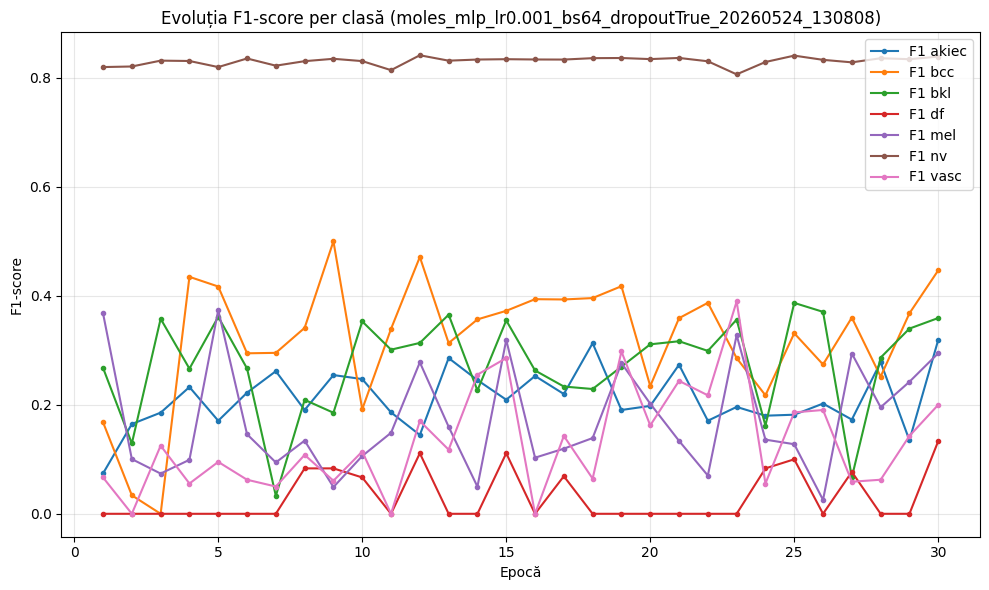

Graficele F1 per clasă salvate în moles_mlp_lr0.001_bs64_dropoutTrue_20260524_130808_f1_per_class.png


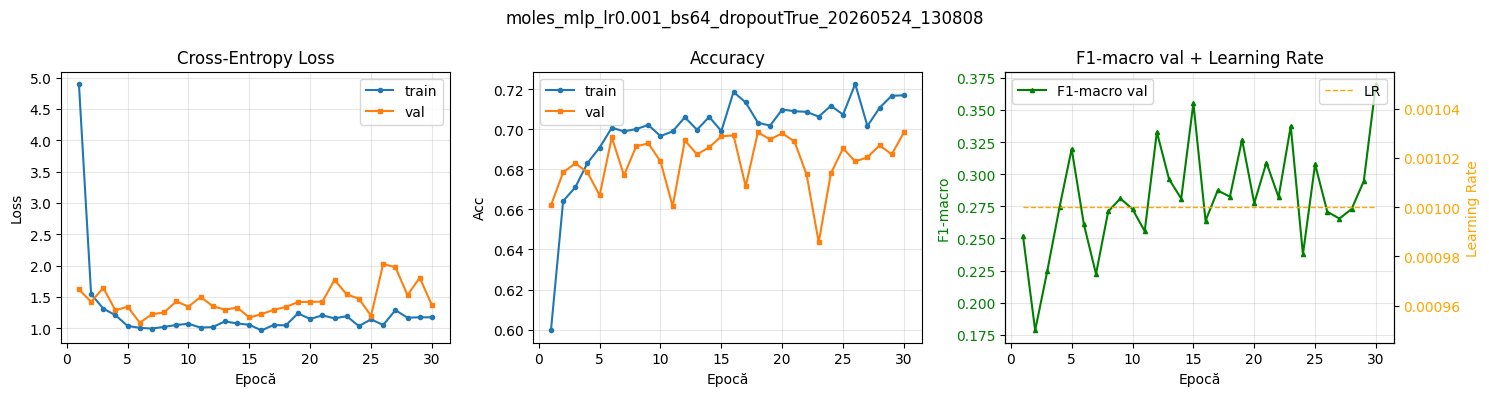

Graficele salvate în moles_mlp_lr0.001_bs64_dropoutTrue_20260524_130808_curves.png


In [ ]:
plot_f1_per_class(history, class_names, run_name=RUN_NAME)

# ─── Grafice loss/acc/f1 ──────────────────────────────────────────────────────
plot_history(history, run_name=RUN_NAME)

## 7. Graficele curbelor de train/val

Cerinţa din temă: **grafice cu curbele de train și test** + comentarea cazurilor de overfit/underfit.

In [ ]:
def plot_history(history, run_name="experiment"):
    """
    Afișează 3 grafice:
    1. Curba de Loss (train vs val)
    2. Curba de Accuracy (train vs val)
    3. Curba de F1-macro (val) + Learning Rate

    Cum interpretăm:
    - OVERFITTING: train loss scade continuu, val loss crește → prea multă complexitate
    - UNDERFITTING: ambele curbe sunt ridicate și stagnează → model prea simplu / lr prea mic
    - IDEAL: ambele curbe scad și se apropie
    """
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(run_name, fontsize=12)

    # Grafic 1: Loss
    axes[0].plot(epochs, history["train_loss"], label="train", marker="o", markersize=3)
    axes[0].plot(epochs, history["val_loss"],   label="val",   marker="s", markersize=3)
    axes[0].set_title("Cross-Entropy Loss")
    axes[0].set_xlabel("Epocă")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Grafic 2: Accuracy
    axes[1].plot(epochs, history["train_acc"], label="train", marker="o", markersize=3)
    axes[1].plot(epochs, history["val_acc"],   label="val",   marker="s", markersize=3)
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epocă")
    axes[1].set_ylabel("Acc")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    # Grafic 3: F1-macro + LR
    ax3 = axes[2]
    ax3.plot(epochs, history["val_f1_macro"], color="green", label="F1-macro val",
             marker="^", markersize=3)
    ax3.set_title("F1-macro val + Learning Rate")
    ax3.set_xlabel("Epocă")
    ax3.set_ylabel("F1-macro", color="green")
    ax3.tick_params(axis="y", labelcolor="green")
    ax3.legend(loc="upper left")
    ax3.grid(alpha=0.3)

    if history["lr"]:
        ax3b = ax3.twinx()
        ax3b.plot(epochs, history["lr"], color="orange",
                  linestyle="--", label="LR", linewidth=1)
        ax3b.set_ylabel("Learning Rate", color="orange")
        ax3b.tick_params(axis="y", labelcolor="orange")
        ax3b.legend(loc="upper right")

    plt.tight_layout()
    plt.savefig(f"{run_name}_curves.png", dpi=150)
    plt.show()
    print(f"Graficele salvate în {run_name}_curves.png")

def plot_f1_per_class(history, class_names, run_name="experiment"):
    """
    Plotează evoluția F1-score per clasă pe parcursul antrenării.
    """
    if not history or not history.get("f1_per_class"):
        print("Nu există date de F1 per clasă în istoric.")
        return

    epochs = range(1, len(history["f1_per_class"]) + 1)

    # Convertim lista de array-uri de F1 în array-uri per clasă
    f1_scores_per_class = np.array(history["f1_per_class"]).T # Transpunem

    plt.figure(figsize=(10, 6))
    for i, class_name in enumerate(class_names):
        plt.plot(epochs, f1_scores_per_class[i], label=f"F1 {class_name}", marker='o', markersize=3)

    plt.title(f"Evoluția F1-score per clasă ({run_name})")
    plt.xlabel("Epocă")
    plt.ylabel("F1-score")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{run_name}_f1_per_class.png", dpi=150)
    plt.show()
    print(f"Graficele F1 per clasă salvate în {run_name}_f1_per_class.png")


# Apelează după antrenare:
# plot_history(history, run_name=RUN_NAME)


In [ ]:
# ── Configurarea numelui experimentului ──────────────────────────────────────
# Numele trebuie să fie descriptiv — va apărea ca o curbă separată în TensorBoard!
# Schimbă 'mlp' cu 'cnn' / 'resnet18' etc. când rulezi alte modele.
RUN_NAME = (
    f"faces_mlp"
    f"_lr{LR}"
    f"_bs{BATCH_SIZE}"
    f"_dropout{True}"
    f"_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
)
print(f"Experiment: {RUN_NAME}")

writer = SummaryWriter(log_dir=f"runs/{RUN_NAME}")

Experiment: faces_mlp_lr0.001_bs64_dropoutTrue_20260524_133146


In [ ]:
NUM_EPOCHS = 30
best_val_loss = float("inf")
os.makedirs("checkpoints", exist_ok=True)

# Re-initialize criterion and optimizer for the current model (model_moles)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_faces.parameters(), lr=LR, weight_decay=1e-4)

# Define class names for the moles dataset

class_names = FACE_CLASSES # This is needed for f1_per_class calculation and plotting

history = {
    "train_loss": [], "train_acc": [],
    "val_loss":   [], "val_acc":   [],
    "val_f1_macro": [], "val_f1_micro": [],
    "f1_per_class": [],   # Add this line to initialize f1_per_class history
    "lr": []
}

# ─── Logăm un batch de imagini la pasul 0 ────────────────────────────────────
images, labels = next(iter(train_loader_moles))
grid = torchvision.utils.make_grid(images[:16], nrow=4, normalize=True)
writer.add_image("Train/sample_batch", grid, global_step=0)

for epoch in range(NUM_EPOCHS):
    # ── Antrenare ────────────────────────────────────────────────────────────
    tr_loss, tr_acc = train_one_epoch(model_faces, train_loader_faces, criterion, optimizer, device)

    # ── Evaluare ────────────────────────────────────────────────────────────
    va_loss, va_acc, va_f1_mac, va_f1_mic, all_labels, all_preds = evaluate(model_faces, val_loader_faces, criterion, device) # Capture all_labels and all_preds

    # ── F1 per clasă ──────────────────────────────────────────────────────────
    f1_per_class = f1_score(all_labels, all_preds, average=None, zero_division=0) # Calculate f1_per_class
    history["f1_per_class"].append(f1_per_class) # Append to history

    # ── Scheduler ────────────────────────────────────────────────────────────
    # scheduler.step(va_loss)  # ReduceLROnPlateau se apelează cu val_loss

    # ── Salvarea celui mai bun model ─────────────────────────────────────────
    if va_loss < best_val_loss:
         best_val_loss = va_loss
         torch.save(model_faces.state_dict(), f"checkpoints/{RUN_NAME}_best.pt")

    # ── Logging în TensorBoard ───────────────────────────────────────────────
    # Tag-urile cu '/' sunt grupate pe același grafic în TensorBoard!
    writer.add_scalar("Loss/train",     tr_loss,   epoch)
    writer.add_scalar("Loss/val",       va_loss,   epoch)
    writer.add_scalar("Acc/train",      tr_acc,    epoch)
    writer.add_scalar("Acc/val",        va_acc,    epoch)
    writer.add_scalar("F1_macro/val",   va_f1_mac, epoch)
    writer.add_scalar("F1_micro/val",   va_f1_mic, epoch)
    # Log F1 per class to TensorBoard
    for i, (name, f1) in enumerate(zip(class_names, f1_per_class)):
        writer.add_scalar(f"F1_per_class/{name}", f1, epoch)
    current_lr = optimizer.param_groups[0]["lr"]
    writer.add_scalar("LR", current_lr, epoch)

    # ── Afișare în terminal ──────────────────────────────────────────────────
    print(f"Epocă {epoch+1:02d}/{NUM_EPOCHS} | "
           f"train loss={tr_loss:.4f} acc={tr_acc:.3f} | "
           f"val loss={va_loss:.4f} acc={va_acc:.3f} "
           f"F1mac={va_f1_mac:.3f} F1mic={va_f1_mic:.3f} "
           f"lr={current_lr:.6f}")
    # Add F1 per class to terminal output
    f1_str = " | ".join(f"{n}={f:.2f}" for n, f in zip(class_names, f1_per_class))
    print(f"  F1/clasă: {f1_str}")

    # ── Salvăm în history ────────────────────────────────────────────────────
    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["val_loss"].append(va_loss)
    history["val_acc"].append(va_acc)
    history["val_f1_macro"].append(va_f1_mac)
    history["val_f1_micro"].append(va_f1_mic)
    history["lr"].append(current_lr)
    # șterge această linie după ce decomentezi blocurile de mai sus

# ─── Închidem writer-ul TensorBoard ─────────────────────────────────────────
# IMPORTANT: fără writer.close(), ultimele valori s-ar putea să nu fie salvate pe disc!
writer.close()
print("Antrenarea s-a terminat!")

Epocă 01/30 | train loss=3.5921 acc=0.459 | val loss=1.6725 acc=0.546 F1mac=0.354 F1mic=0.546 lr=0.001000
  F1/clasă: Surprise=0.50 | Fear=0.28 | Disgust=0.06 | Happiness=0.74 | Sadness=0.32 | Anger=0.16 | Neutral=0.43
Epocă 02/30 | train loss=1.5591 acc=0.549 | val loss=1.4568 acc=0.564 F1mac=0.382 F1mic=0.564 lr=0.001000
  F1/clasă: Surprise=0.48 | Fear=0.03 | Disgust=0.15 | Happiness=0.77 | Sadness=0.39 | Anger=0.39 | Neutral=0.46
Epocă 03/30 | train loss=1.3291 acc=0.592 | val loss=1.2630 acc=0.581 F1mac=0.437 F1mic=0.581 lr=0.001000
  F1/clasă: Surprise=0.57 | Fear=0.39 | Disgust=0.07 | Happiness=0.79 | Sadness=0.43 | Anger=0.35 | Neutral=0.46
Epocă 04/30 | train loss=1.2475 acc=0.605 | val loss=1.2128 acc=0.612 F1mac=0.456 F1mic=0.612 lr=0.001000
  F1/clasă: Surprise=0.56 | Fear=0.36 | Disgust=0.09 | Happiness=0.79 | Sadness=0.43 | Anger=0.40 | Neutral=0.56
Epocă 05/30 | train loss=1.2019 acc=0.619 | val loss=1.1784 acc=0.623 F1mac=0.486 F1mic=0.623 lr=0.001000
  F1/clasă: Surpri

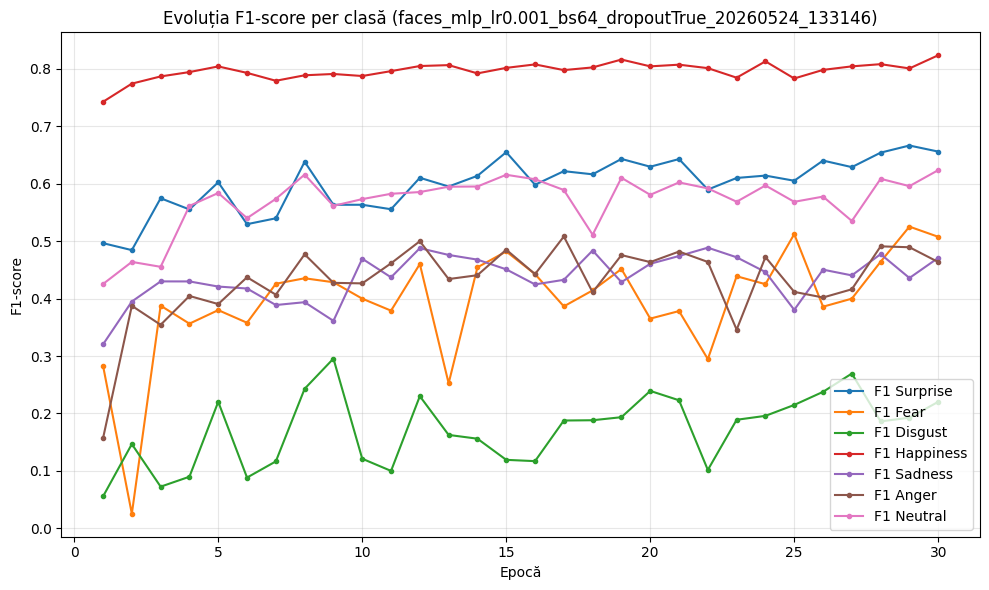

Graficele F1 per clasă salvate în faces_mlp_lr0.001_bs64_dropoutTrue_20260524_133146_f1_per_class.png


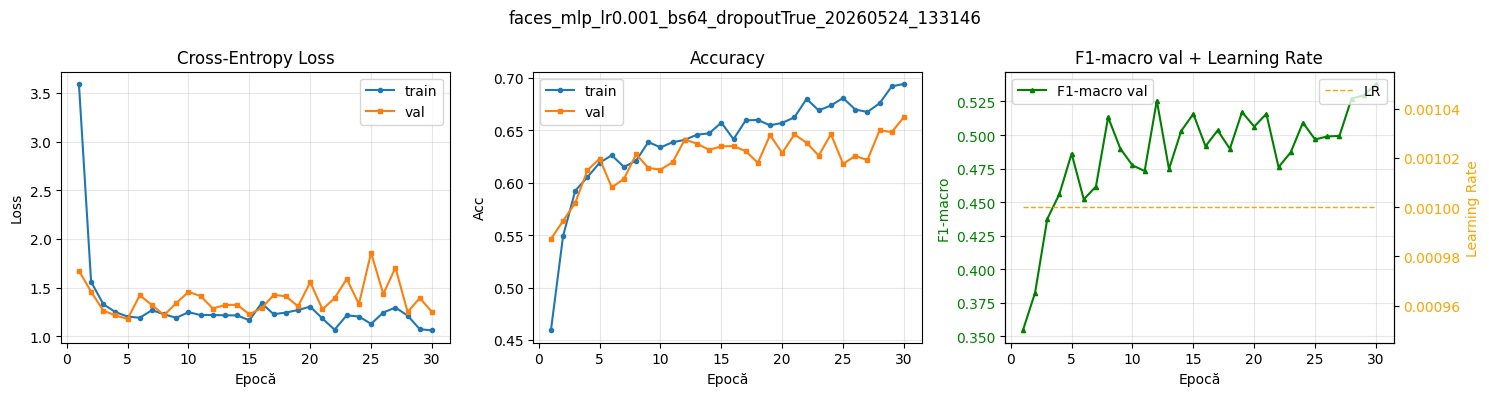

Graficele salvate în faces_mlp_lr0.001_bs64_dropoutTrue_20260524_133146_curves.png


In [ ]:
plot_f1_per_class(history, class_names, run_name=RUN_NAME)

# ─── Grafice loss/acc/f1 ──────────────────────────────────────────────────────
plot_history(history, run_name=RUN_NAME)

## 8. Matricea de confuzie și metricile finale

Cerinţa din raport: **matrice de confuzie + accuracy, F1-macro, F1-micro** pe fiecare set de date.

In [26]:
#import matplotlib.pyplot as plt
import numpy as np

def plot_confusion_matrix(all_labels, all_preds, class_names, title="Matrice de confuzie"):
    """
    Plotează matricea de confuzie normalizată (procente pe rând).
    Normalizarea pe rând arată recall-ul per clasă.
    """
    cm = confusion_matrix(all_labels, all_preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # normalizare pe rând

    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(cm_norm, interpolation="nearest", cmap="Blues")
    plt.colorbar(im, ax=ax)

    ax.set_xticks(range(len(class_names)))
    ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticklabels(class_names)
    ax.set_xlabel("Predicție")
    ax.set_ylabel("Etichetă reală")
    ax.set_title(title)

    # Scriem procentele în celule
    thresh = cm_norm.max() / 2.0
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            ax.text(j, i, f"{cm_norm[i, j]:.2f}",
                    ha="center", va="center",
                    color="white" if cm_norm[i, j] > thresh else "black",
                    fontsize=8)
    plt.tight_layout()
    plt.show()
    return cm


def print_metrics(all_labels, all_preds, class_names):
    """Afișează un tabel cu metrici per clasă."""
    from sklearn.metrics import classification_report, accuracy_score

    acc      = accuracy_score(all_labels, all_preds)
    f1_mac   = f1_score(all_labels, all_preds, average="macro",  zero_division=0)
    f1_mic   = f1_score(all_labels, all_preds, average="micro",  zero_division=0)

    print(f"Accuracy : {acc:.4f}")
    print(f"F1-macro : {f1_mac:.4f}")
    print(f"F1-micro : {f1_mic:.4f}")
    print()
    print(classification_report(all_labels, all_preds,
                                 target_names=class_names, zero_division=0))


# ─── Exemplu pentru skin moles ────────────────────────────────────────────────
MOLES_CLASSES = ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]

# ─── Exemplu pentru expresii faciale ─────────────────────────────────────────
FACE_CLASSES = ["Surprise", "Fear", "Disgust", "Happiness", "Sadness", "Anger", "Neutral"]

# Apelează după evaluate:
# _, _, _, _, preds, labels = evaluate(model, val_loader, criterion, device)
# cm = plot_confusion_matrix(labels, preds, FACE_CLASSES, title="MLP – expresii faciale")
print_metrics(labels, preds, FACE_CLASSES)
print("Funcțiile de evaluare finală sunt gata. Decomentează după antrenare.")

NameError: name 'labels' is not defined

In [ ]:
class CNN(nn.Module):
    """
    CNN simplu pentru clasificare imagini.
    Arhitectura:
      Conv2d → ReLU → MaxPool
      Conv2d → ReLU → MaxPool
      Flatten → Linear(input_dim, 512) → ReLU → Dropout(0.3)
             → Linear(512, num_classes)
    Args:
        input_channels: numărul de canale ale imaginii (3 pentru RGB)
        img_height: înălțimea imaginii
        img_width: lățimea imaginii
        num_classes: numărul de clase
        use_dropout: dacă True, adaugă strat Dropout
    """
    def __init__(self, input_channels=3, img_height=64, img_width=128, num_classes=2, use_dropout=True):
        super().__init__()

        # ── Blocuri convoluționale ────────────────────────────────────────────
        self.features = nn.Sequential(
            # Bloc 1
            nn.Conv2d(input_channels, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Bloc 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )

        feat_h = img_height // 4
        feat_w = img_width  // 4
        input_dim = 64 * feat_h * feat_w

        # ── Clasificator (același ca MLP) ─────────────────────────────────────
        layers = [
            nn.Flatten(),
            nn.Linear(input_dim, 512),
            nn.ReLU(inplace=True),
        ]
        if use_dropout:
            layers.append(nn.Dropout(0.3))
        layers.append(nn.Linear(512, num_classes))
        self.classifier = nn.Sequential(*layers)

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


# ── Instanțiere ──────────────────────────────────────────────────────────────
model = CNN(
    input_channels=3,
    img_height=64,
    img_width=128,
    num_classes=7,
    use_dropout=True,
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"SimpleCNN – parametri antrenabili: {n_params:,}")
print(model)

SimpleCNN – parametri antrenabili: 16,800,711
CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=32768, out_features=512, bias=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=7, bias=True)
  )
)


In [ ]:
model_moles_cnn = CNN(
    input_channels=3,
    img_height=100, # Corrected from 130 to 100
    img_width=100,
    num_classes=7,
    use_dropout=True,
).to(device)

n_params = sum(p.numel() for p in model_moles_cnn.parameters() if p.requires_grad)
print(f"SimpleCNN – parametri antrenabili: {n_params:,}")
print(model_moles_cnn)

SimpleCNN – parametri antrenabili: 20,503,495
CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=40000, out_features=512, bias=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=7, bias=True)
  )
)


In [ ]:
model_faces_cnn = CNN(
    input_channels=3,
    img_height=100,
    img_width=100,
    num_classes=7,
    use_dropout=True,
).to(device)

n_params = sum(p.numel() for p in model_faces.parameters() if p.requires_grad)
print(f"SimpleCNN – parametri antrenabili: {n_params:,}")
print(model_faces)

SimpleCNN – parametri antrenabili: 15,364,103
MLP(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=30000, out_features=512, bias=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=7, bias=True)
  )
)


In [ ]:
# ── Configurarea numelui experimentului ──────────────────────────────────────
# Numele trebuie să fie descriptiv — va apărea ca o curbă separată în TensorBoard!
# Schimbă 'mlp' cu 'cnn' / 'resnet18' etc. când rulezi alte modele.
RUN_NAME = (
    f"moles_cnn"
    f"_lr{LR}"
    f"_bs{BATCH_SIZE}"
    f"_dropout{True}"
    f"_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
)
print(f"Experiment: {RUN_NAME}")

writer = SummaryWriter(log_dir=f"runs/{RUN_NAME}")

Experiment: moles_cnn_lr0.001_bs64_dropoutTrue_20260524_135013


In [ ]:
# Rulează asta înainte de training:
images, labels = next(iter(train_loader_moles))
print("Images min/max:", images.min().item(), images.max().item())
print("Labels:", labels[:10])
print("Labels unice:", labels.unique())

Images min/max: -5.422694683074951 2.2606256008148193
Labels: tensor([5, 5, 5, 5, 5, 4, 4, 2, 5, 5])
Labels unice: tensor([1, 2, 4, 5])


In [ ]:
NUM_EPOCHS = 30
best_val_loss = float("inf")
os.makedirs("checkpoints", exist_ok=True)

# Re-initialize criterion and optimizer for the current model (model_moles)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_moles_cnn.parameters(), lr=LR, weight_decay=1e-4)

# Define class names for the moles dataset

class_names = FACE_CLASSES # This is needed for f1_per_class calculation and plotting

history = {
    "train_loss": [], "train_acc": [],
    "val_loss":   [], "val_acc":   [],
    "val_f1_macro": [], "val_f1_micro": [],
    "f1_per_class": [],   # Add this line to initialize f1_per_class history
    "lr": []
}

# ─── Logăm un batch de imagini la pasul 0 ────────────────────────────────────
images, labels = next(iter(train_loader_moles))
grid = torchvision.utils.make_grid(images[:16], nrow=4, normalize=True)
writer.add_image("Train/sample_batch", grid, global_step=0)

for epoch in range(NUM_EPOCHS):
    # ── Antrenare ────────────────────────────────────────────────────────────
    tr_loss, tr_acc = train_one_epoch(model_moles_cnn, train_loader_moles, criterion, optimizer, device)

    # ── Evaluare ────────────────────────────────────────────────────────────
    va_loss, va_acc, va_f1_mac, va_f1_mic, all_labels, all_preds = evaluate(model_moles_cnn, val_loader_moles, criterion, device) # Capture all_labels and all_preds

    # ── F1 per clasă ──────────────────────────────────────────────────────────
    f1_per_class = f1_score(all_labels, all_preds, average=None, zero_division=0) # Calculate f1_per_class
    history["f1_per_class"].append(f1_per_class) # Append to history

    # ── Scheduler ────────────────────────────────────────────────────────────
    # scheduler.step(va_loss)  # ReduceLROnPlateau se apelează cu val_loss

    # ── Salvarea celui mai bun model ─────────────────────────────────────────
    if va_loss < best_val_loss:
         best_val_loss = va_loss
         torch.save(model_moles_cnn.state_dict(), f"checkpoints/{RUN_NAME}_best.pt")

    # ── Logging în TensorBoard ───────────────────────────────────────────────
    # Tag-urile cu '/' sunt grupate pe același grafic în TensorBoard!
    writer.add_scalar("Loss/train",     tr_loss,   epoch)
    writer.add_scalar("Loss/val",       va_loss,   epoch)
    writer.add_scalar("Acc/train",      tr_acc,    epoch)
    writer.add_scalar("Acc/val",        va_acc,    epoch)
    writer.add_scalar("F1_macro/val",   va_f1_mac, epoch)
    writer.add_scalar("F1_micro/val",   va_f1_mic, epoch)
    # Log F1 per class to TensorBoard
    for i, (name, f1) in enumerate(zip(class_names, f1_per_class)):
        writer.add_scalar(f"F1_per_class/{name}", f1, epoch)
    current_lr = optimizer.param_groups[0]["lr"]
    writer.add_scalar("LR", current_lr, epoch)

    # ── Afișare în terminal ──────────────────────────────────────────────────
    print(f"Epocă {epoch+1:02d}/{NUM_EPOCHS} | "
           f"train loss={tr_loss:.4f} acc={tr_acc:.3f} | "
           f"val loss={va_loss:.4f} acc={va_acc:.3f} "
           f"F1mac={va_f1_mac:.3f} F1mic={va_f1_mic:.3f} "
           f"lr={current_lr:.6f}")
    # Add F1 per class to terminal output
    f1_str = " | ".join(f"{n}={f:.2f}" for n, f in zip(class_names, f1_per_class))
    print(f"  F1/clasă: {f1_str}")

    # ── Salvăm în history ────────────────────────────────────────────────────
    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["val_loss"].append(va_loss)
    history["val_acc"].append(va_acc)
    history["val_f1_macro"].append(va_f1_mac)
    history["val_f1_micro"].append(va_f1_mic)
    history["lr"].append(current_lr)
    # șterge această linie după ce decomentezi blocurile de mai sus

# ─── Închidem writer-ul TensorBoard ─────────────────────────────────────────
# IMPORTANT: fără writer.close(), ultimele valori s-ar putea să nu fie salvate pe disc!
writer.close()
print("Antrenarea s-a terminat!")

Epocă 01/30 | train loss=1.0883 acc=0.652 | val loss=0.9107 acc=0.671 F1mac=0.127 F1mic=0.671 lr=0.001000
  F1/clasă: Surprise=0.06 | Fear=0.00 | Disgust=0.03 | Happiness=0.00 | Sadness=0.00 | Anger=0.80 | Neutral=0.00
Epocă 02/30 | train loss=0.8147 acc=0.692 | val loss=0.7891 acc=0.713 F1mac=0.317 F1mic=0.713 lr=0.001000
  F1/clasă: Surprise=0.11 | Fear=0.48 | Disgust=0.30 | Happiness=0.00 | Sadness=0.21 | Anger=0.85 | Neutral=0.26
Epocă 03/30 | train loss=0.7441 acc=0.722 | val loss=0.7961 acc=0.718 F1mac=0.331 F1mic=0.718 lr=0.001000
  F1/clasă: Surprise=0.03 | Fear=0.47 | Disgust=0.32 | Happiness=0.00 | Sadness=0.17 | Anger=0.85 | Neutral=0.48
Epocă 04/30 | train loss=0.6842 acc=0.744 | val loss=0.7489 acc=0.730 F1mac=0.390 F1mic=0.730 lr=0.001000
  F1/clasă: Surprise=0.30 | Fear=0.39 | Disgust=0.38 | Happiness=0.00 | Sadness=0.39 | Anger=0.86 | Neutral=0.41
Epocă 05/30 | train loss=0.6440 acc=0.761 | val loss=0.7613 acc=0.714 F1mac=0.427 F1mic=0.714 lr=0.001000
  F1/clasă: Surpri

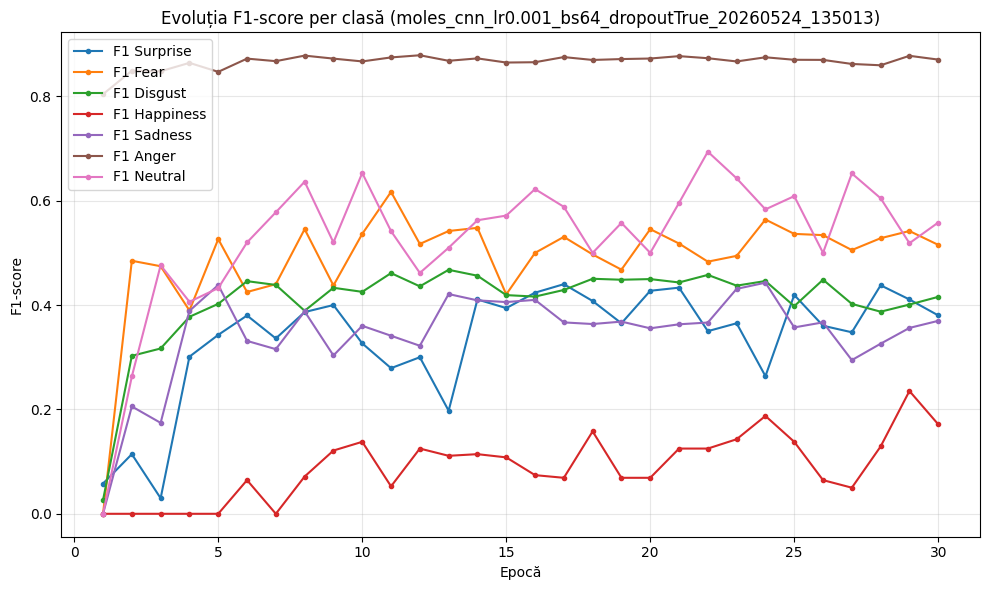

Graficele F1 per clasă salvate în moles_cnn_lr0.001_bs64_dropoutTrue_20260524_135013_f1_per_class.png


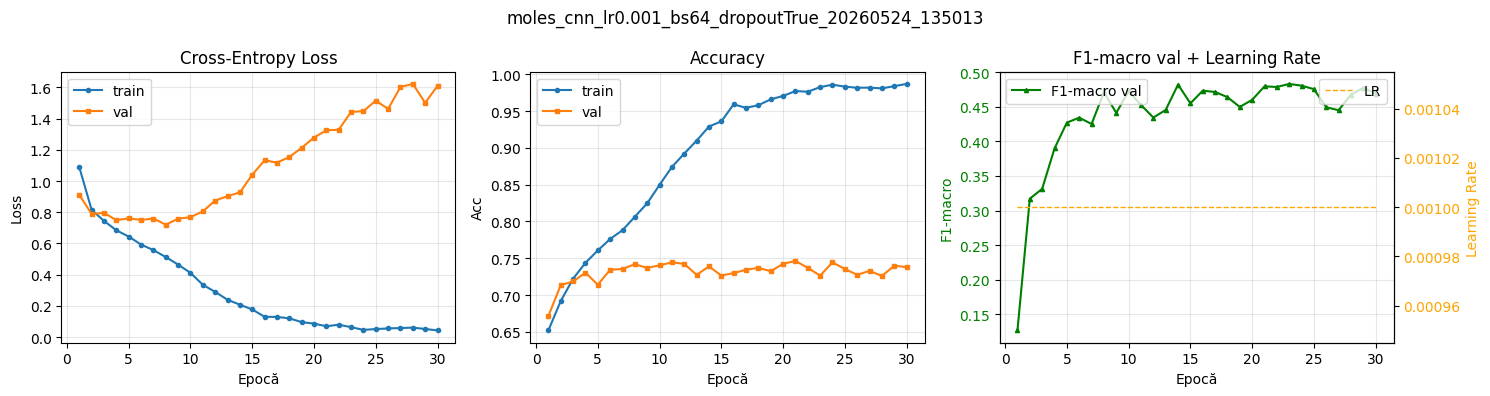

Graficele salvate în moles_cnn_lr0.001_bs64_dropoutTrue_20260524_135013_curves.png


In [ ]:
plot_f1_per_class(history, class_names, run_name=RUN_NAME)

# ─── Grafice loss/acc/f1 ──────────────────────────────────────────────────────
plot_history(history, run_name=RUN_NAME)

In [ ]:
# ── Configurarea numelui experimentului ──────────────────────────────────────
# Numele trebuie să fie descriptiv — va apărea ca o curbă separată în TensorBoard!
# Schimbă 'mlp' cu 'cnn' / 'resnet18' etc. când rulezi alte modele.
RUN_NAME = (
    f"faces_cnn"
    f"_lr{LR}"
    f"_bs{BATCH_SIZE}"
    f"_dropout{True}"
    f"_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
)
print(f"Experiment: {RUN_NAME}")

writer = SummaryWriter(log_dir=f"runs/{RUN_NAME}")

Experiment: faces_cnn_lr0.001_bs64_dropoutTrue_20260524_140157


In [ ]:
NUM_EPOCHS = 30
best_val_loss = float("inf")
os.makedirs("checkpoints", exist_ok=True)

# Re-initialize criterion and optimizer for the current model (model_moles)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_faces_cnn.parameters(), lr=LR, weight_decay=1e-4)

# Define class names for the moles dataset

class_names = FACE_CLASSES # This is needed for f1_per_class calculation and plotting

history = {
    "train_loss": [], "train_acc": [],
    "val_loss":   [], "val_acc":   [],
    "val_f1_macro": [], "val_f1_micro": [],
    "f1_per_class": [],   # Add this line to initialize f1_per_class history
    "lr": []
}

# ─── Logăm un batch de imagini la pasul 0 ────────────────────────────────────
images, labels = next(iter(train_loader_moles))
grid = torchvision.utils.make_grid(images[:16], nrow=4, normalize=True)
writer.add_image("Train/sample_batch", grid, global_step=0)

for epoch in range(NUM_EPOCHS):
    # ── Antrenare ────────────────────────────────────────────────────────────
    tr_loss, tr_acc = train_one_epoch(model_faces_cnn, train_loader_faces, criterion, optimizer, device)

    # ── Evaluare ────────────────────────────────────────────────────────────
    va_loss, va_acc, va_f1_mac, va_f1_mic, all_labels, all_preds = evaluate(model_faces_cnn, val_loader_faces, criterion, device) # Capture all_labels and all_preds

    # ── F1 per clasă ──────────────────────────────────────────────────────────
    f1_per_class = f1_score(all_labels, all_preds, average=None, zero_division=0) # Calculate f1_per_class
    history["f1_per_class"].append(f1_per_class) # Append to history

    # ── Scheduler ────────────────────────────────────────────────────────────
    # scheduler.step(va_loss)  # ReduceLROnPlateau se apelează cu val_loss

    # ── Salvarea celui mai bun model ─────────────────────────────────────────
    if va_loss < best_val_loss:
         best_val_loss = va_loss
         torch.save(model_faces_cnn.state_dict(), f"checkpoints/{RUN_NAME}_best.pt")

    # ── Logging în TensorBoard ───────────────────────────────────────────────
    # Tag-urile cu '/' sunt grupate pe același grafic în TensorBoard!
    writer.add_scalar("Loss/train",     tr_loss,   epoch)
    writer.add_scalar("Loss/val",       va_loss,   epoch)
    writer.add_scalar("Acc/train",      tr_acc,    epoch)
    writer.add_scalar("Acc/val",        va_acc,    epoch)
    writer.add_scalar("F1_macro/val",   va_f1_mac, epoch)
    writer.add_scalar("F1_micro/val",   va_f1_mic, epoch)
    # Log F1 per class to TensorBoard
    for i, (name, f1) in enumerate(zip(class_names, f1_per_class)):
        writer.add_scalar(f"F1_per_class/{name}", f1, epoch)
    current_lr = optimizer.param_groups[0]["lr"]
    writer.add_scalar("LR", current_lr, epoch)

    # ── Afișare în terminal ──────────────────────────────────────────────────
    print(f"Epocă {epoch+1:02d}/{NUM_EPOCHS} | "
           f"train loss={tr_loss:.4f} acc={tr_acc:.3f} | "
           f"val loss={va_loss:.4f} acc={va_acc:.3f} "
           f"F1mac={va_f1_mac:.3f} F1mic={va_f1_mic:.3f} "
           f"lr={current_lr:.6f}")
    # Add F1 per class to terminal output
    f1_str = " | ".join(f"{n}={f:.2f}" for n, f in zip(class_names, f1_per_class))
    print(f"  F1/clasă: {f1_str}")

    # ── Salvăm în history ────────────────────────────────────────────────────
    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["val_loss"].append(va_loss)
    history["val_acc"].append(va_acc)
    history["val_f1_macro"].append(va_f1_mac)
    history["val_f1_micro"].append(va_f1_mic)
    history["lr"].append(current_lr)
    # șterge această linie după ce decomentezi blocurile de mai sus

# ─── Închidem writer-ul TensorBoard ─────────────────────────────────────────
# IMPORTANT: fără writer.close(), ultimele valori s-ar putea să nu fie salvate pe disc!
writer.close()
print("Antrenarea s-a terminat!")

Epocă 01/30 | train loss=1.5447 acc=0.467 | val loss=1.1259 acc=0.608 F1mac=0.400 F1mic=0.608 lr=0.001000
  F1/clasă: Surprise=0.58 | Fear=0.20 | Disgust=0.00 | Happiness=0.79 | Sadness=0.23 | Anger=0.39 | Neutral=0.60
Epocă 02/30 | train loss=1.0536 acc=0.630 | val loss=0.9820 acc=0.648 F1mac=0.510 F1mic=0.648 lr=0.001000
  F1/clasă: Surprise=0.64 | Fear=0.32 | Disgust=0.26 | Happiness=0.80 | Sadness=0.46 | Anger=0.51 | Neutral=0.58
Epocă 03/30 | train loss=0.9150 acc=0.676 | val loss=0.8999 acc=0.686 F1mac=0.574 F1mic=0.686 lr=0.001000
  F1/clasă: Surprise=0.69 | Fear=0.46 | Disgust=0.34 | Happiness=0.83 | Sadness=0.52 | Anger=0.54 | Neutral=0.63
Epocă 04/30 | train loss=0.8166 acc=0.710 | val loss=0.9160 acc=0.684 F1mac=0.546 F1mic=0.684 lr=0.001000
  F1/clasă: Surprise=0.65 | Fear=0.42 | Disgust=0.24 | Happiness=0.84 | Sadness=0.57 | Anger=0.48 | Neutral=0.63
Epocă 05/30 | train loss=0.7393 acc=0.734 | val loss=0.8183 acc=0.712 F1mac=0.605 F1mic=0.712 lr=0.001000
  F1/clasă: Surpri

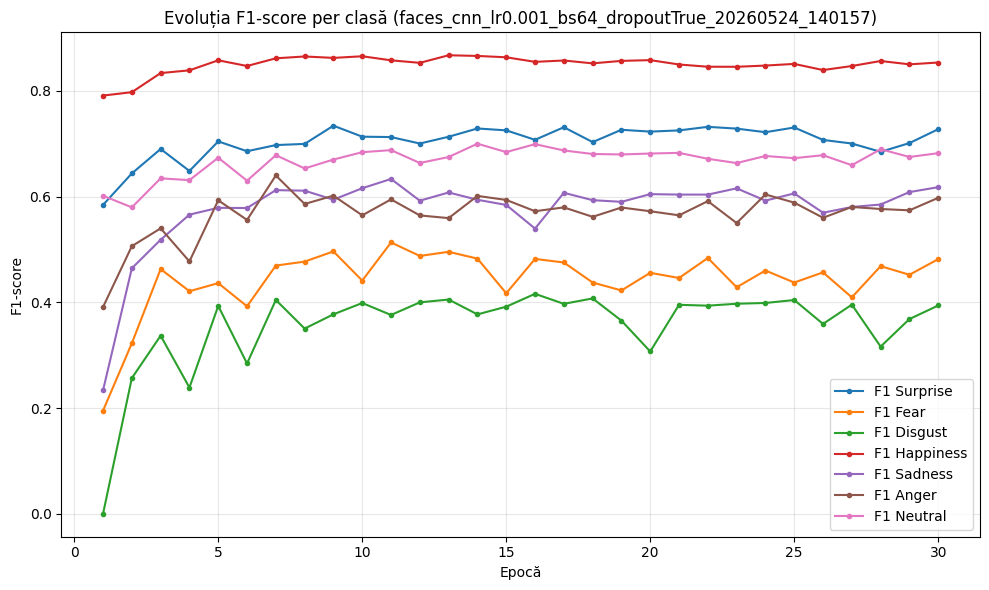

Graficele F1 per clasă salvate în faces_cnn_lr0.001_bs64_dropoutTrue_20260524_140157_f1_per_class.png


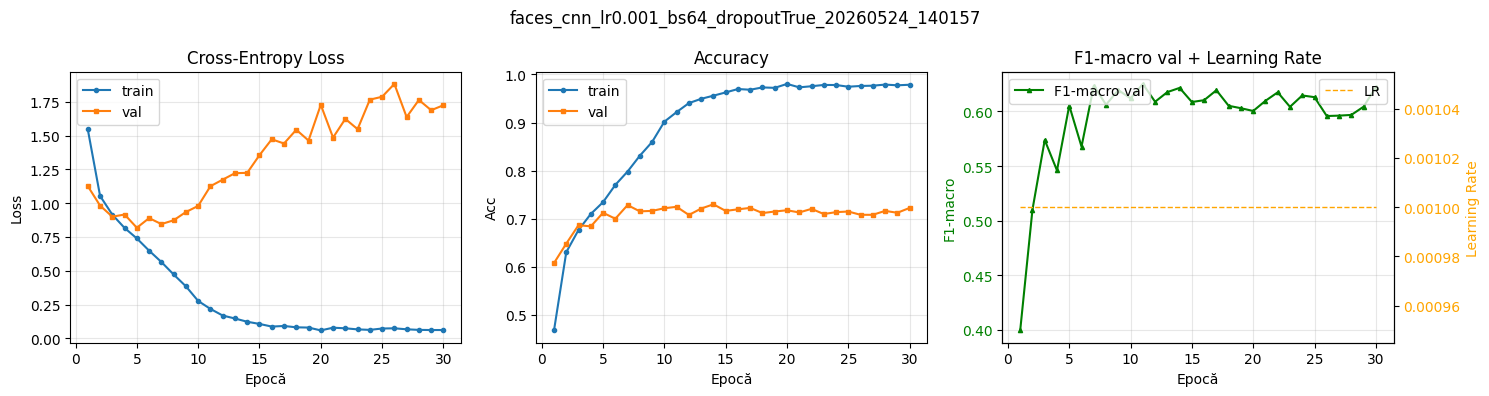

Graficele salvate în faces_cnn_lr0.001_bs64_dropoutTrue_20260524_140157_curves.png


In [ ]:
plot_f1_per_class(history, class_names, run_name=RUN_NAME)

# ─── Grafice loss/acc/f1 ──────────────────────────────────────────────────────
plot_history(history, run_name=RUN_NAME)

## 9. TensorBoard – cum îl porneşti

**În terminal** (din directorul proiectului):
```bash
tensorboard --logdir runs
```
Deschide browserul la `http://localhost:6006`

**În Jupyter Notebook** (dacă preferi inline):

In [ ]:
# Rulează TensorBoard direct în notebook (funcționează în Jupyter/Colab)
%load_ext tensorboard
%tensorboard --logdir runs

print("Decomentează magic commands de mai sus pentru TensorBoard inline.")

## 10. Logarea histogramelor de ponderi și a hiperparametrilor

Util pentru debugging (ex: gradient vanishing/exploding) și pentru tab-ul HPARAMS din TensorBoard.

In [ ]:
def log_weights_and_hparams(writer, model, optimizer, epoch,
                             val_acc, val_loss,
                             hparams_dict=None):
    """
    Logează histogramele ponderilor și gradienților la fiecare epocă.
    La final, logăm și hiperparametrii pentru tab-ul HPARAMS.
    """
    # Histograme ponderi + gradienti
    for name, param in model.named_parameters():
        writer.add_histogram(f"weights/{name}", param.data, global_step=epoch)
        if param.grad is not None:
            writer.add_histogram(f"grads/{name}", param.grad, global_step=epoch)

    # Hiperparametri (o singură dată, la ultima epocă)
    if hparams_dict is not None:
        writer.add_hparams(
            hparams_dict,
            {
                "hparam/val_acc":  val_acc,
                "hparam/val_loss": val_loss,
            }
        )

# Exemplu de apel la sfârșitul antrenării:
# log_weights_and_hparams(
#     writer, model, optimizer, epoch=NUM_EPOCHS,
#     val_acc=history["val_acc"][-1],
#     val_loss=history["val_loss"][-1],
#     hparams_dict={"lr": LR, "batch_size": BATCH_SIZE,
#                   "model": "MLP", "dropout": True}
# )
print("Funcția de logging ponderi/hparams e gata.")

## 11. Checklist pentru raport (Secțiunile 1 & 2)

Bifează înainte de trimitere:

- [ ] Descrisă arhitectura MLP (număr straturi, dimensiuni, funcții de activare, normalizare)
- [ ] Documentat procesul de antrenare (nr epoci, optimizator, lr scheduling)
- [ ] Grafice curbe de train/val Loss și Accuracy
- [ ] Comentariu despre overfitting/underfitting
- [ ] Matrice de confuzie pe val set
- [ ] Metrice: accuracy, F1-macro, F1-micro
- [ ] Screenshot TensorBoard cu curbele (sau graficele din matplotlib)
- [ ] Ablație dropout (cu/fără) – tabel sau grafic comparativ

In [ ]:
class CNN_cu_BatchNorm2d(nn.Module):
    """
    CNN simplu pentru clasificare imagini.
    Arhitectura:
      Conv2d → BatchNorm2d → ReLU → MaxPool
      Conv2d → BatchNorm2d → ReLU → MaxPool
      Flatten → Linear(input_dim, 512) → BatchNorm1d(512) → ReLU → Dropout(0.3)
             → Linear(512, num_classes)
    Args:
        input_channels: numărul de canale ale imaginii (3 pentru RGB)
        img_height: înălțimea imaginii
        img_width: lățimea imaginii
        num_classes: numărul de clase
        use_dropout: dacă True, adaugă strat Dropout
    """
    def __init__(self, input_channels=3, img_height=64, img_width=128, num_classes=2, use_dropout=True):
        super().__init__()

        # ── Blocuri convoluționale ────────────────────────────────────────────
        self.features = nn.Sequential(
            # Bloc 1
            nn.Conv2d(input_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),       # ← după Conv2d, înainte de ReLU
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),          # H/2, W/2

            # Bloc 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),       # ← după Conv2d, înainte de ReLU
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),          # H/4, W/4
        )

        # Calculăm automat input_dim pentru primul Linear
        feat_h = img_height // 4
        feat_w = img_width  // 4
        input_dim = 64 * feat_h * feat_w

        # ── Clasificator ──────────────────────────────────────────────────────
        layers = [
            nn.Flatten(),
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),      # ← BatchNorm1d pentru straturi liniare
            nn.ReLU(inplace=True),
        ]
        if use_dropout:
            layers.append(nn.Dropout(0.5))
        layers.append(nn.Linear(512, num_classes))
        self.classifier = nn.Sequential(*layers)

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [ ]:
model_moles_cnn_bn2 = CNN_cu_BatchNorm2d(
    input_channels=3,
    img_height=100, # Corrected from 130 to 100
    img_width=100,
    num_classes=7,
    use_dropout=True,
).to(device)

n_params = sum(p.numel() for p in model_moles_cnn_bn2.parameters() if p.requires_grad)
print(f"SimpleCNN_cu_BatchNorm2d – parametri antrenabili: {n_params:,}")
print(model_moles_cnn_bn2)

SimpleCNN_cu_BatchNorm2d – parametri antrenabili: 20,504,711
CNN_cu_BatchNorm2d(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=40000, out_features=512, bias=True)
    (2): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ReLU(inplace=True)
    (4): Dropout(p=0.5, inplace=False)
    (5): Linear(in_features=512, out_features=7

In [ ]:
model_faces_cnn_bn2 = CNN_cu_BatchNorm2d(
    input_channels=3,
    img_height=100,
    img_width=100,
    num_classes=7,
    use_dropout=True,
).to(device)

n_params = sum(p.numel() for p in model_faces_cnn_bn2.parameters() if p.requires_grad)
print(f"SimpleCNN_cu_BatchNorm2d – parametri antrenabili: {n_params:,}")
print(model_faces_cnn_bn2)

SimpleCNN_cu_BatchNorm2d – parametri antrenabili: 20,504,711
CNN_cu_BatchNorm2d(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=40000, out_features=512, bias=True)
    (2): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ReLU(inplace=True)
    (4): Dropout(p=0.5, inplace=False)
    (5): Linear(in_features=512, out_features=7

In [ ]:
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds  = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss    = criterion(outputs, labels)
            preds   = outputs.argmax(dim=1)

            total_loss += loss.item() * images.size(0)
            correct    += (preds == labels).sum().item()
            total      += images.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / total
    avg_acc  = correct / total
    f1_mac   = f1_score(all_labels, all_preds, average="macro",  zero_division=0)
    f1_mic   = f1_score(all_labels, all_preds, average="micro",  zero_division=0)

    return avg_loss, avg_acc, f1_mac, f1_mic, all_labels, all_preds

In [ ]:
LR = 1e-3
BATCH_SIZE = 64
# ── Configurarea numelui experimentului ──────────────────────────────────────
# Numele trebuie să fie descriptiv — va apărea ca o curbă separată în TensorBoard!
# Schimbă 'mlp' cu 'cnn' / 'resnet18' etc. când rulezi alte modele.
RUN_NAME = (
    f"moles_cnn_bn2"
    f"_lr{LR}"
    f"_bs{BATCH_SIZE}"
    f"_dropout{True}"
    f"_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
)
print(f"Experiment: {RUN_NAME}")

writer = SummaryWriter(log_dir=f"runs/{RUN_NAME}")

Experiment: moles_cnn_bn2_lr0.001_bs64_dropoutTrue_20260524_141320



── Best model! Classification Report ──────────────────────────
              precision    recall  f1-score   support

       akiec       0.35      0.09      0.15        65
         bcc       0.47      0.42      0.44       103
         bkl       0.48      0.14      0.22       220
          df       0.00      0.00      0.00        23
         mel       0.47      0.11      0.18       222
          nv       0.74      0.98      0.84      1341
        vasc       0.60      0.10      0.18        29

    accuracy                           0.71      2003
   macro avg       0.44      0.26      0.29      2003
weighted avg       0.64      0.71      0.64      2003

Epocă 01/30 | train loss=0.9038 acc=0.672 | val loss=0.7956 acc=0.709 F1mac=0.286 F1mic=0.709 lr=0.001000
  F1/clasă: akiec=0.15 | bcc=0.44 | bkl=0.22 | df=0.00 | mel=0.18 | nv=0.84 | vasc=0.18

── Best model! Classification Report ──────────────────────────
              precision    recall  f1-score   support

       akiec       0.75 

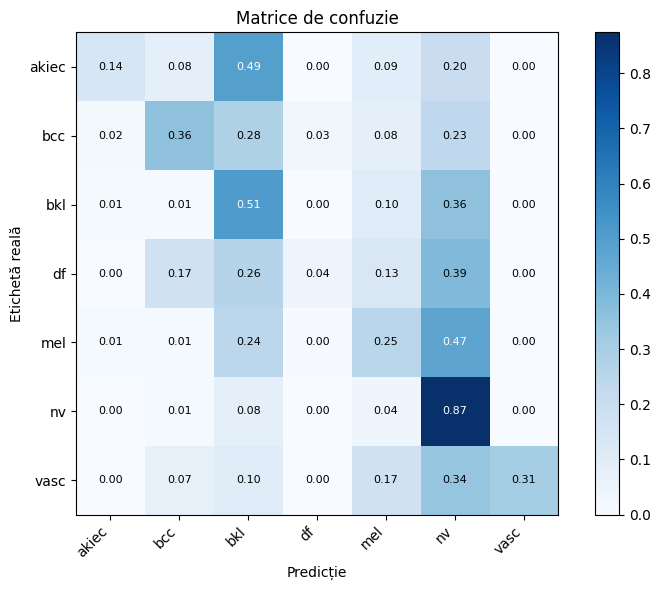

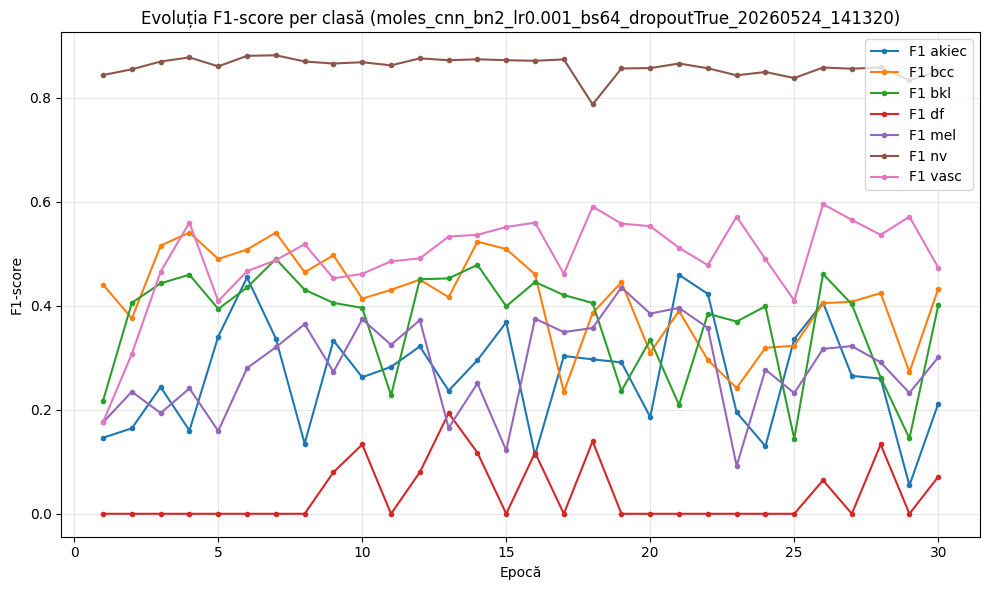

Graficele F1 per clasă salvate în moles_cnn_bn2_lr0.001_bs64_dropoutTrue_20260524_141320_f1_per_class.png


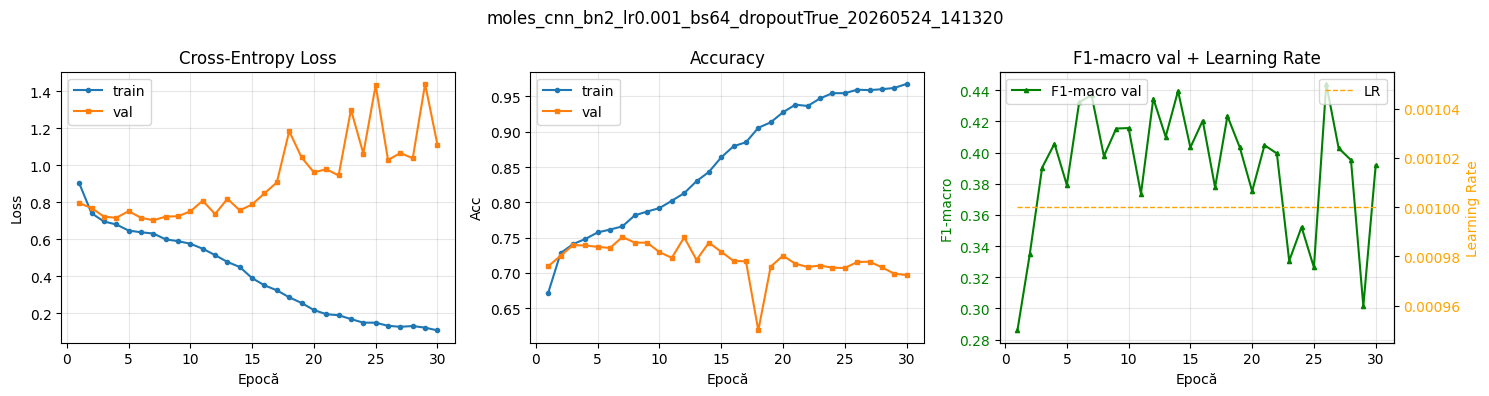

Graficele salvate în moles_cnn_bn2_lr0.001_bs64_dropoutTrue_20260524_141320_curves.png


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import seaborn as sns
import numpy as np

NUM_EPOCHS = 30
best_val_loss = float("inf")
os.makedirs("checkpoints", exist_ok=True)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_moles_cnn_bn2.parameters(), lr=LR, weight_decay=1e-3)

# ── Numele claselor ───────────────────────────────────────────────────────────
class_names = MOLES_CLASSES # Folosim MOLES_CLASSES pentru moles dataset

history = {
    "train_loss": [], "train_acc": [],
    "val_loss":   [], "val_acc":   [],
    "val_f1_macro": [], "val_f1_micro": [],
    "f1_per_class": [],   # ← nou
    "lr": []
}

# ─── Logăm un batch de imagini la pasul 0 ────────────────────────────────────
images, labels = next(iter(train_loader_moles))
grid = torchvision.utils.make_grid(images[:16], nrow=4, normalize=True)
writer.add_image("Train/sample_batch", grid, global_step=0)

for epoch in range(NUM_EPOCHS):
    # ── Antrenare ─────────────────────────────────────────────────────────────
    tr_loss, tr_acc = train_one_epoch(model_moles_cnn_bn2, train_loader_moles, criterion, optimizer, device)

    # ── Evaluare ──────────────────────────────────────────────────────────────
    va_loss, va_acc, va_f1_mac, va_f1_mic, all_labels, all_preds = evaluate(
        model_moles_cnn_bn2, val_loader_moles, criterion, device
    )

    # ── F1 per clasă ──────────────────────────────────────────────────────────
    f1_per_class = f1_score(all_labels, all_preds, average=None, zero_division=0)
    history["f1_per_class"].append(f1_per_class)

    # ── Scheduler ─────────────────────────────────────────────────────────────
    # scheduler.step(va_loss)

    # ── Salvarea celui mai bun model ──────────────────────────────────────────
    if va_loss < best_val_loss:
        best_val_loss = va_loss
        torch.save(model_moles_cnn_bn2.state_dict(), f"checkpoints/{RUN_NAME}_best.pt")

        # ── Classification report doar când avem best model ───────────────────
        print("\n── Best model! Classification Report ──────────────────────────")
        print(classification_report(all_labels, all_preds,
                                    target_names=class_names, zero_division=0))

    # ── Logging TensorBoard ───────────────────────────────────────────────────
    writer.add_scalar("Loss/train",   tr_loss,   epoch)
    writer.add_scalar("Loss/val",     va_loss,   epoch)
    writer.add_scalar("Acc/train",    tr_acc,    epoch)
    writer.add_scalar("Acc/val",      va_acc,    epoch)
    writer.add_scalar("F1_macro/val", va_f1_mac, epoch)
    writer.add_scalar("F1_micro/val", va_f1_mic, epoch)
    for i, (name, f1) in enumerate(zip(class_names, f1_per_class)):
        writer.add_scalar(f"F1_per_class/{name}", f1, epoch)  # ← grafic separat per clasă
    current_lr = optimizer.param_groups[0]["lr"]
    writer.add_scalar("LR", current_lr, epoch)

    # ── Afișare terminal ──────────────────────────────────────────────────────
    print(f"Epocă {epoch+1:02d}/{NUM_EPOCHS} | "
          f"train loss={tr_loss:.4f} acc={tr_acc:.3f} | "
          f"val loss={va_loss:.4f} acc={va_acc:.3f} "
          f"F1mac={va_f1_mac:.3f} F1mic={va_f1_mic:.3f} "
          f"lr={current_lr:.6f}")
    # F1 per clasă inline
    f1_str = " | ".join(f"{n}={f:.2f}" for n, f in zip(class_names, f1_per_class))
    print(f"  F1/clasă: {f1_str}")

    # ── History ───────────────────────────────────────────────────────────────
    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["val_loss"].append(va_loss)
    history["val_acc"].append(va_acc)
    history["val_f1_macro"].append(va_f1_mac)
    history["val_f1_micro"].append(va_f1_mic)
    history["lr"].append(current_lr)

# ─── Închide TensorBoard ──────────────────────────────────────────────────────
writer.close()
print("Antrenarea s-a terminat!")

# ─── Confusion matrix finală (pe ultimul epoch) ───────────────────────────────
plot_confusion_matrix(all_labels, all_preds, class_names)

# ─── F1 per clasă în timp ─────────────────────────────────────────────────────
plot_f1_per_class(history, class_names, run_name=RUN_NAME)

# ─── Grafice loss/acc/f1 ──────────────────────────────────────────────────────
plot_history(history, run_name=RUN_NAME)


In [ ]:
# ── Configurarea numelui experimentului ──────────────────────────────────────
# Numele trebuie să fie descriptiv — va apărea ca o curbă separată în TensorBoard!
# Schimbă 'mlp' cu 'cnn' / 'resnet18' etc. când rulezi alte modele.
RUN_NAME = (
    f"faces_cnn_bn2"
    f"_lr{LR}"
    f"_bs{BATCH_SIZE}"
    f"_dropout{True}"
    f"_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
)
print(f"Experiment: {RUN_NAME}")

writer = SummaryWriter(log_dir=f"runs/{RUN_NAME}")

Experiment: faces_cnn_bn2_lr0.001_bs64_dropoutTrue_20260524_143349



── Best model! Classification Report ──────────────────────────
              precision    recall  f1-score   support

    Surprise       0.76      0.62      0.69       329
        Fear       0.90      0.12      0.21        74
     Disgust       0.60      0.13      0.22       160
   Happiness       0.67      0.96      0.79      1185
     Sadness       0.63      0.44      0.52       478
       Anger       0.58      0.49      0.53       162
     Neutral       0.67      0.59      0.62       680

    accuracy                           0.67      3068
   macro avg       0.69      0.48      0.51      3068
weighted avg       0.67      0.67      0.64      3068

Epocă 01/30 | train loss=1.1042 acc=0.603 | val loss=0.8963 acc=0.671 F1mac=0.512 F1mic=0.671 lr=0.001000
  F1/clasă: Surprise=0.69 | Fear=0.21 | Disgust=0.22 | Happiness=0.79 | Sadness=0.52 | Anger=0.53 | Neutral=0.62

── Best model! Classification Report ──────────────────────────
              precision    recall  f1-score   support


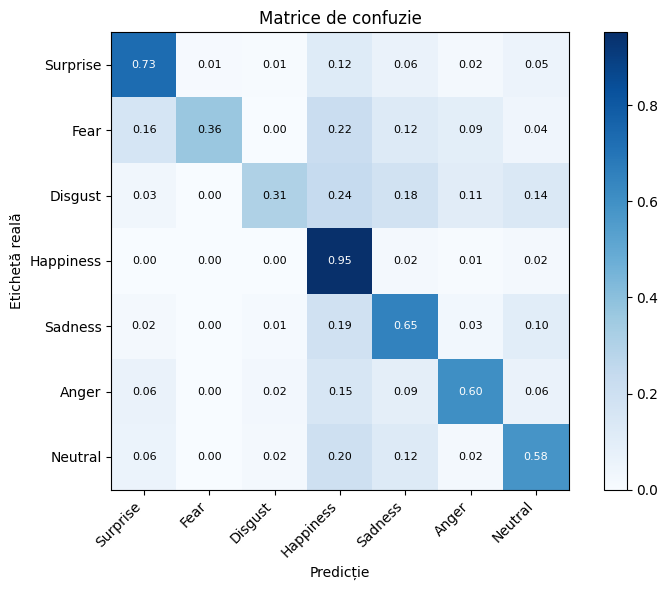

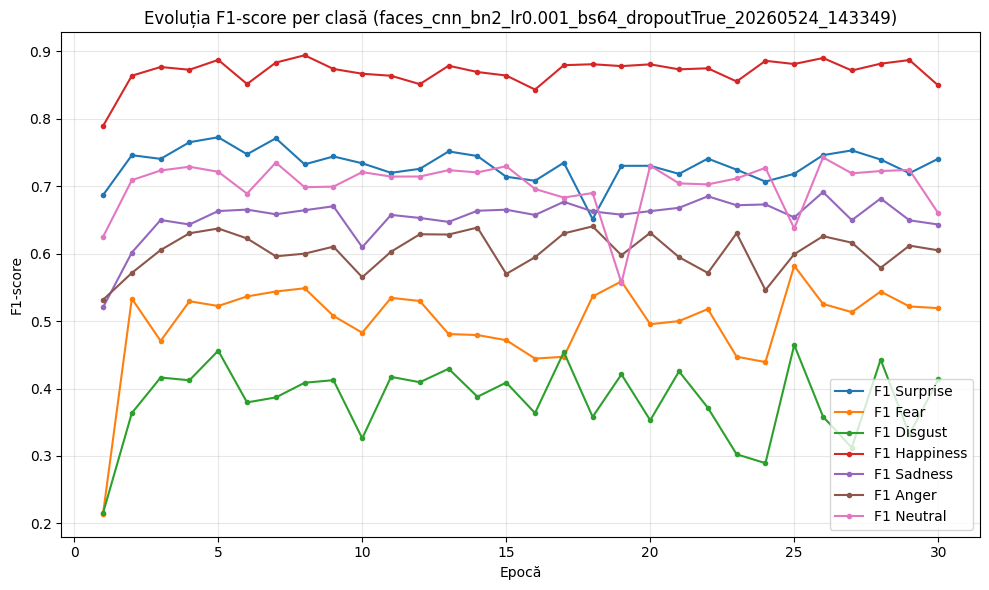

Graficele F1 per clasă salvate în faces_cnn_bn2_lr0.001_bs64_dropoutTrue_20260524_143349_f1_per_class.png


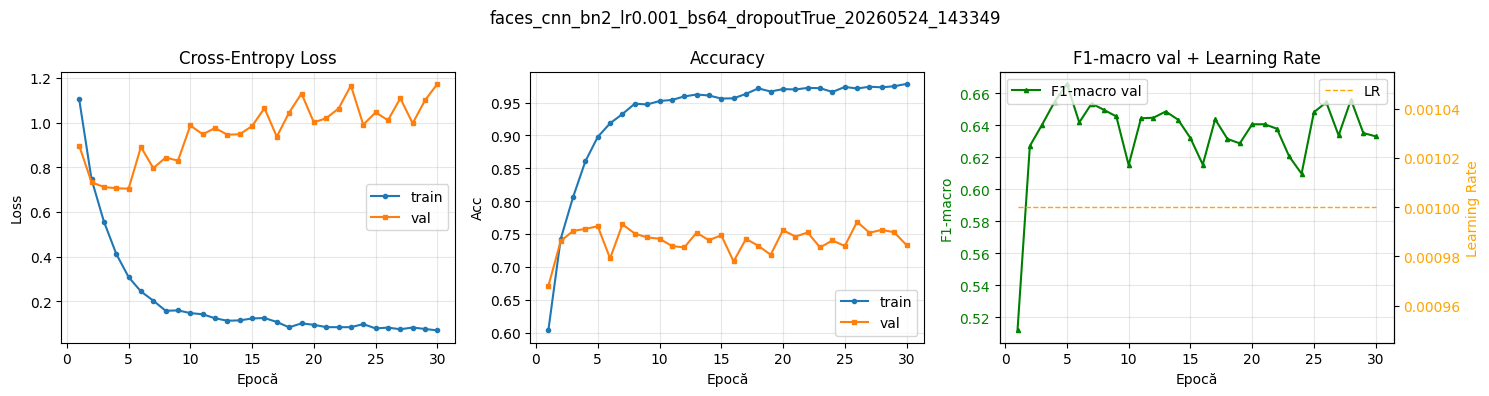

Graficele salvate în faces_cnn_bn2_lr0.001_bs64_dropoutTrue_20260524_143349_curves.png


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

def plot_confusion_matrix(all_labels, all_preds, class_names, title="Matrice de confuzie"):
    """
    Plotează matricea de confuzie normalizată (procente pe rând).
    Normalizarea pe rând arată recall-ul per clasă.
    """
    cm = confusion_matrix(all_labels, all_preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # normalizare pe rând

    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(cm_norm, interpolation="nearest", cmap="Blues")
    plt.colorbar(im, ax=ax)

    ax.set_xticks(range(len(class_names)))
    ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticklabels(class_names)
    ax.set_xlabel("Predicție")
    ax.set_ylabel("Etichetă reală")
    ax.set_title(title)

    # Scriem procentele în celule
    thresh = cm_norm.max() / 2.0
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            ax.text(j, i, f"{cm_norm[i, j]:.2f}",
                    ha="center", va="center",
                    color="white" if cm_norm[i, j] > thresh else "black",
                    fontsize=8)
    plt.tight_layout()
    plt.show()
    return cm

def plot_history(history, run_name="experiment"):
    """
    Afișează 3 grafice:
    1. Curba de Loss (train vs val)
    2. Curba de Accuracy (train vs val)
    3. Curba de F1-macro (val) + Learning Rate

    Cum interpretăm:
    - OVERFITTING: train loss scade continuu, val loss crește → prea multă complexitate
    - UNDERFITTING: ambele curbe sunt ridicate și stagnează → model prea simplu / lr prea mic
    - IDEAL: ambele curbe scad și se apropie
    """
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(run_name, fontsize=12)

    # Grafic 1: Loss
    axes[0].plot(epochs, history["train_loss"], label="train", marker="o", markersize=3)
    axes[0].plot(epochs, history["val_loss"],   label="val",   marker="s", markersize=3)
    axes[0].set_title("Cross-Entropy Loss")
    axes[0].set_xlabel("Epocă")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Grafic 2: Accuracy
    axes[1].plot(epochs, history["train_acc"], label="train", marker="o", markersize=3)
    axes[1].plot(epochs, history["val_acc"],   label="val",   marker="s", markersize=3)
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epocă")
    axes[1].set_ylabel("Acc")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    # Grafic 3: F1-macro + LR
    ax3 = axes[2]
    ax3.plot(epochs, history["val_f1_macro"], color="green", label="F1-macro val",
             marker="^", markersize=3)
    ax3.set_title("F1-macro val + Learning Rate")
    ax3.set_xlabel("Epocă")
    ax3.set_ylabel("F1-macro", color="green")
    ax3.tick_params(axis="y", labelcolor="green")
    ax3.legend(loc="upper left")
    ax3.grid(alpha=0.3)

    if history["lr"]:
        ax3b = ax3.twinx()
        ax3b.plot(epochs, history["lr"], color="orange",
                  linestyle="--", label="LR", linewidth=1)
        ax3b.set_ylabel("Learning Rate", color="orange")
        ax3b.tick_params(axis="y", labelcolor="orange")
        ax3b.legend(loc="upper right")

    plt.tight_layout()
    plt.savefig(f"{run_name}_curves.png", dpi=150)
    plt.show()
    print(f"Graficele salvate în {run_name}_curves.png")

def plot_f1_per_class(history, class_names, run_name="experiment"):
    """
    Plotează evoluția F1-score per clasă pe parcursul antrenării.
    """
    if not history or not history.get("f1_per_class"):
        print("Nu există date de F1 per clasă în istoric.")
        return

    epochs = range(1, len(history["f1_per_class"]) + 1)

    # Convertim lista de array-uri de F1 în array-uri per clasă
    f1_scores_per_class = np.array(history["f1_per_class"]).T # Transpunem

    plt.figure(figsize=(10, 6))
    for i, class_name in enumerate(class_names):
        plt.plot(epochs, f1_scores_per_class[i], label=f"F1 {class_name}", marker='o', markersize=3)

    plt.title(f"Evoluția F1-score per clasă ({run_name})")
    plt.xlabel("Epocă")
    plt.ylabel("F1-score")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{run_name}_f1_per_class.png", dpi=150)
    plt.show()
    print(f"Graficele F1 per clasă salvate în {run_name}_f1_per_class.png")

NUM_EPOCHS = 30
best_val_loss = float("inf")
os.makedirs("checkpoints", exist_ok=True)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_faces_cnn_bn2.parameters(), lr=LR, weight_decay=1e-4)

# ── Numele claselor ───────────────────────────────────────────────────────────
class_names = FACE_CLASSES # Folosim MOLES_CLASSES pentru moles dataset

history = {
    "train_loss": [], "train_acc": [],
    "val_loss":   [], "val_acc":   [],
    "val_f1_macro": [], "val_f1_micro": [],
    "f1_per_class": [],   # ← nou
    "lr": []
}

# ─── Logăm un batch de imagini la pasul 0 ────────────────────────────────────
images, labels = next(iter(train_loader_faces))
grid = torchvision.utils.make_grid(images[:16], nrow=4, normalize=True)
writer.add_image("Train/sample_batch", grid, global_step=0)

for epoch in range(NUM_EPOCHS):
    # ── Antrenare ─────────────────────────────────────────────────────────────
    tr_loss, tr_acc = train_one_epoch(model_faces_cnn_bn2, train_loader_faces, criterion, optimizer, device)

    # ── Evaluare ──────────────────────────────────────────────────────────────
    va_loss, va_acc, va_f1_mac, va_f1_mic, all_labels, all_preds = evaluate(
        model_faces_cnn_bn2, val_loader_faces, criterion, device
    )

    # ── F1 per clasă ──────────────────────────────────────────────────────────
    f1_per_class = f1_score(all_labels, all_preds, average=None, zero_division=0)
    history["f1_per_class"].append(f1_per_class)

    # ── Scheduler ─────────────────────────────────────────────────────────────
    # scheduler.step(va_loss)

    # ── Salvarea celui mai bun model ──────────────────────────────────────────
    if va_loss < best_val_loss:
        best_val_loss = va_loss
        torch.save(model_faces_cnn_bn2.state_dict(), f"checkpoints/{RUN_NAME}_best.pt")

        # ── Classification report doar când avem best model ───────────────────
        print("\n── Best model! Classification Report ──────────────────────────")
        print(classification_report(all_labels, all_preds,
                                    target_names=class_names, zero_division=0))

    # ── Logging TensorBoard ───────────────────────────────────────────────────
    writer.add_scalar("Loss/train",   tr_loss,   epoch)
    writer.add_scalar("Loss/val",     va_loss,   epoch)
    writer.add_scalar("Acc/train",    tr_acc,    epoch)
    writer.add_scalar("Acc/val",      va_acc,    epoch)
    writer.add_scalar("F1_macro/val", va_f1_mac, epoch)
    writer.add_scalar("F1_micro/val", va_f1_mic, epoch)
    for i, (name, f1) in enumerate(zip(class_names, f1_per_class)):
        writer.add_scalar(f"F1_per_class/{name}", f1, epoch)  # ← grafic separat per clasă
    current_lr = optimizer.param_groups[0]["lr"]
    writer.add_scalar("LR", current_lr, epoch)

    # ── Afișare terminal ──────────────────────────────────────────────────────
    print(f"Epocă {epoch+1:02d}/{NUM_EPOCHS} | "
          f"train loss={tr_loss:.4f} acc={tr_acc:.3f} | "
          f"val loss={va_loss:.4f} acc={va_acc:.3f} "
          f"F1mac={va_f1_mac:.3f} F1mic={va_f1_mic:.3f} "
          f"lr={current_lr:.6f}")
    # F1 per clasă inline
    f1_str = " | ".join(f"{n}={f:.2f}" for n, f in zip(class_names, f1_per_class))
    print(f"  F1/clasă: {f1_str}")

    # ── History ───────────────────────────────────────────────────────────────
    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["val_loss"].append(va_loss)
    history["val_acc"].append(va_acc)
    history["val_f1_macro"].append(va_f1_mac)
    history["val_f1_micro"].append(va_f1_mic)
    history["lr"].append(current_lr)

# ─── Închide TensorBoard ──────────────────────────────────────────────────────
writer.close()
print("Antrenarea s-a terminat!")

# ─── Confusion matrix finală (pe ultimul epoch) ───────────────────────────────
plot_confusion_matrix(all_labels, all_preds, class_names)

# ─── F1 per clasă în timp ─────────────────────────────────────────────────────
plot_f1_per_class(history, class_names, run_name=RUN_NAME)

# ─── Grafice loss/acc/f1 ──────────────────────────────────────────────────────
plot_history(history, run_name=RUN_NAME)

In [ ]:
moles_train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),        # OK – leziunea nu are "sus/jos"
    transforms.RandomRotation(degrees=180), # OK – orice unghi e valid
    transforms.ColorJitter(brightness=0.1, contrast=0.1),  # subtil! nu distorsiona culoarea
    transforms.ToTensor(),
    transforms.Normalize(mean=MOLES_MEAN, std=MOLES_STD),
])

moles_val_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MOLES_MEAN, std=MOLES_STD),
])

In [ ]:
faces_train_transform = transforms.Compose([
    transforms.Resize((72, 72)),            # puțin mai mare ca să poată crop
    transforms.RandomCrop(64),             # variabilitate de poziție
    transforms.RandomHorizontalFlip(),     # OK – fețe din ambele direcții
    # NU RandomVerticalFlip – fețe cu capul în jos nu există în date reale
    transforms.RandomRotation(degrees=15), # mic – față prea rotită nu mai e naturală
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=FACE_MEAN, std=FACE_STD),
])

faces_val_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=FACE_MEAN, std=FACE_STD),
])

In [ ]:
model_moles_cnn_bn2_transform = CNN_cu_BatchNorm2d(
    input_channels=3,
    img_height=128,
    img_width=128,
    num_classes=7,
    use_dropout=True,
).to(device)

n_params = sum(p.numel() for p in model_moles_cnn_bn2_transform.parameters() if p.requires_grad)
print(f"SimpleCNN_cu_BatchNorm2d_transform – parametri antrenabili: {n_params:,}")
print(model_moles_cnn_bn2_transform)

SimpleCNN_cu_BatchNorm2d_transform – parametri antrenabili: 33,579,143
CNN_cu_BatchNorm2d(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=65536, out_features=512, bias=True)
    (2): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ReLU(inplace=True)
    (4): Dropout(p=0.5, inplace=False)
    (5): Linear(in_features=512, out_

In [ ]:
# Re-instantiate model_faces_cnn_bn2 with the correct image dimensions
model_faces_cnn_bn2_transform = CNN_cu_BatchNorm2d(
    input_channels=3,
    img_height=64, # Adjusted to match the output of faces_train_transform
    img_width=64,  # Adjusted to match the output of faces_train_transform
    num_classes=7,
    use_dropout=True,
).to(device)

n_params_new = sum(p.numel() for p in model_faces_cnn_bn2_transform.parameters() if p.requires_grad)
print(f"SimpleCNN_cu_BatchNorm2d (new instance) – parametri antrenabili: {n_params_new:,}")
print(model_faces_cnn_bn2_transform)

# You should now use model_faces_cnn_bn2_new in your training loop.

SimpleCNN_cu_BatchNorm2d (new instance) – parametri antrenabili: 8,413,319
CNN_cu_BatchNorm2d(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=16384, out_features=512, bias=True)
    (2): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ReLU(inplace=True)
    (4): Dropout(p=0.5, inplace=False)
    (5): Linear(in_features=512, 

In [ ]:
# Ensure moles_train_transform and moles_val_transform are defined by running cell BWNpCvgh9mRQ first.

# Re-define datasets for moles using the new transformations
train_set_moles_new = ImageCSVDataset(
    "vai-de-pielea-mea/train.csv",
    root_dir="vai-de-pielea-mea/train",
    transform=moles_train_transform,
    label_map=MOLES_LABEL_MAP,
)
val_set_moles_new = ImageCSVDataset(
    "vai-de-pielea-mea/test.csv",
    root_dir="vai-de-pielea-mea/test",
    transform=moles_val_transform,
    label_map=MOLES_LABEL_MAP,
)

# Re-define dataloaders for moles
train_loader_moles_new = DataLoader(train_set_moles_new, batch_size=BATCH_SIZE,
                                  shuffle=True, num_workers=2, drop_last=True)
val_loader_moles_new = DataLoader(val_set_moles_new, batch_size=BATCH_SIZE,
                                shuffle=False, num_workers=2)

print(f"New Moles Train: {len(train_set_moles_new)} exemples, Val: {len(val_set_moles_new)} exemples")

# You should now use train_loader_moles_new and val_loader_moles_new in your training loop.

New Moles Train: 6009 exemples, Val: 2003 exemples


In [ ]:
# Ensure faces_train_transform and faces_val_transform are defined by running cell NzVvULv49u5D first.

# Re-define datasets for faces using the new transformations
train_set_faces_new = ImageFolderDataset(
    "you-re-on-candid-camera/DATASET/train",
    transform=faces_train_transform
)
val_set_faces_new = ImageFolderDataset(
    "you-re-on-candid-camera/DATASET/test",
    transform=faces_val_transform
)

# Re-define dataloaders for faces
train_loader_faces_new = DataLoader(train_set_faces_new, batch_size=BATCH_SIZE,
                                  shuffle=True, num_workers=2, drop_last=True)
val_loader_faces_new = DataLoader(val_set_faces_new, batch_size=BATCH_SIZE,
                                shuffle=False, num_workers=2)

print(f"New Faces Train: {len(train_set_faces_new)} exemples, Val: {len(val_set_faces_new)} exemples")

# You should now use train_loader_faces_new and val_loader_faces_new in your training loop.

New Faces Train: 12271 exemples, Val: 3068 exemples


In [ ]:
LR = 1e-3
BATCH_SIZE = 64
# ── Configurarea numelui experimentului ──────────────────────────────────────
# Numele trebuie să fie descriptiv — va apărea ca o curbă separată în TensorBoard!
# Schimbă 'mlp' cu 'cnn' / 'resnet18' etc. când rulezi alte modele.
RUN_NAME = (
    f"moles_cnn_bn2_transform"
    f"_lr{LR}"
    f"_bs{BATCH_SIZE}"
    f"_dropout{True}"
    f"_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
)
print(f"Experiment: {RUN_NAME}")

writer = SummaryWriter(log_dir=f"runs/{RUN_NAME}")

Experiment: moles_cnn_bn2_transform_lr0.001_bs64_dropoutTrue_20260524_081314



── Best model! Classification Report ──────────────────────────
              precision    recall  f1-score   support

       akiec       0.29      0.29      0.29        66
         bcc       0.03      0.60      0.06         5
         bkl       0.48      0.34      0.40       314
          df       0.00      0.00      0.00         0
         mel       0.17      0.39      0.24        98
          nv       0.89      0.79      0.84      1520
        vasc       0.00      0.00      0.00         0

    accuracy                           0.68      2003
   macro avg       0.27      0.34      0.26      2003
weighted avg       0.77      0.68      0.72      2003

Epocă 01/30 | train loss=0.9841 acc=0.662 | val loss=0.8481 acc=0.680 F1mac=0.259 F1mic=0.680 lr=0.001000
  F1/clasă: akiec=0.29 | bcc=0.06 | bkl=0.40 | df=0.00 | mel=0.24 | nv=0.84 | vasc=0.00

── Best model! Classification Report ──────────────────────────
              precision    recall  f1-score   support

       akiec       0.18 

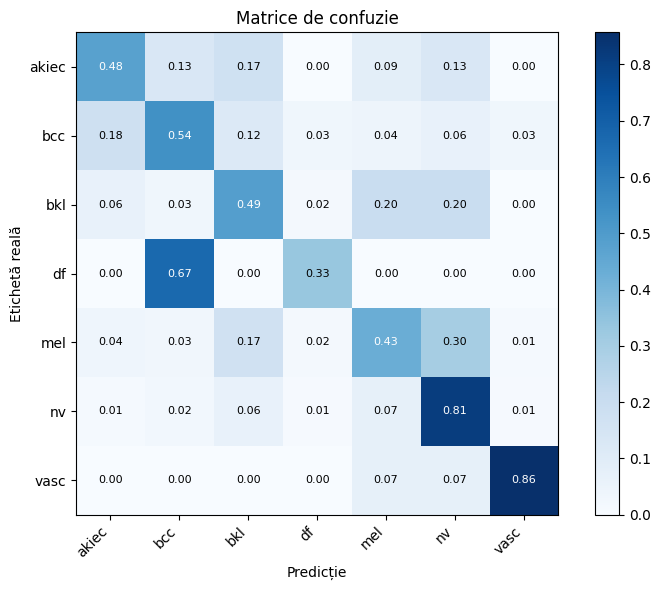

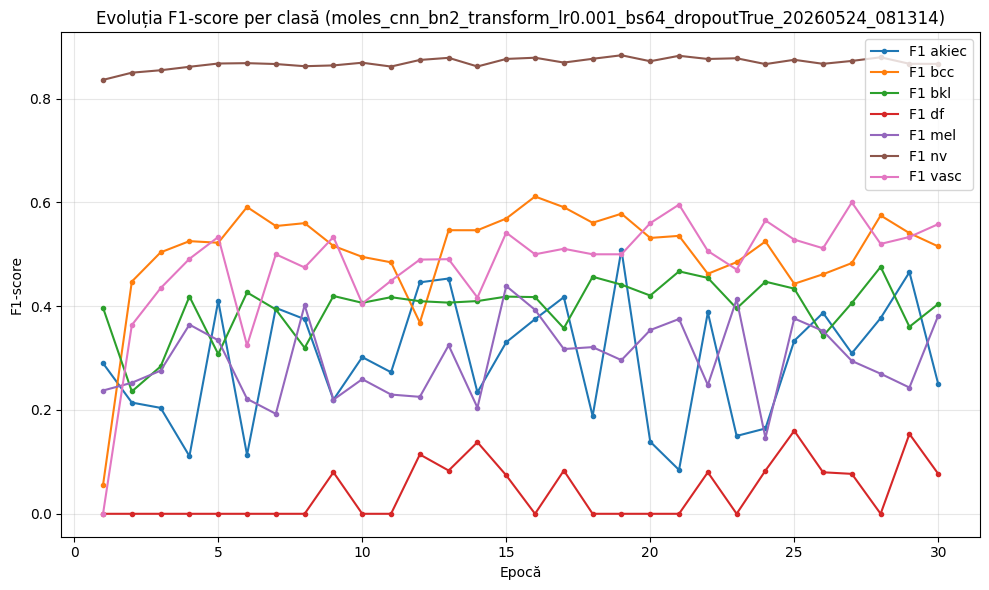

Graficele F1 per clasă salvate în moles_cnn_bn2_transform_lr0.001_bs64_dropoutTrue_20260524_081314_f1_per_class.png


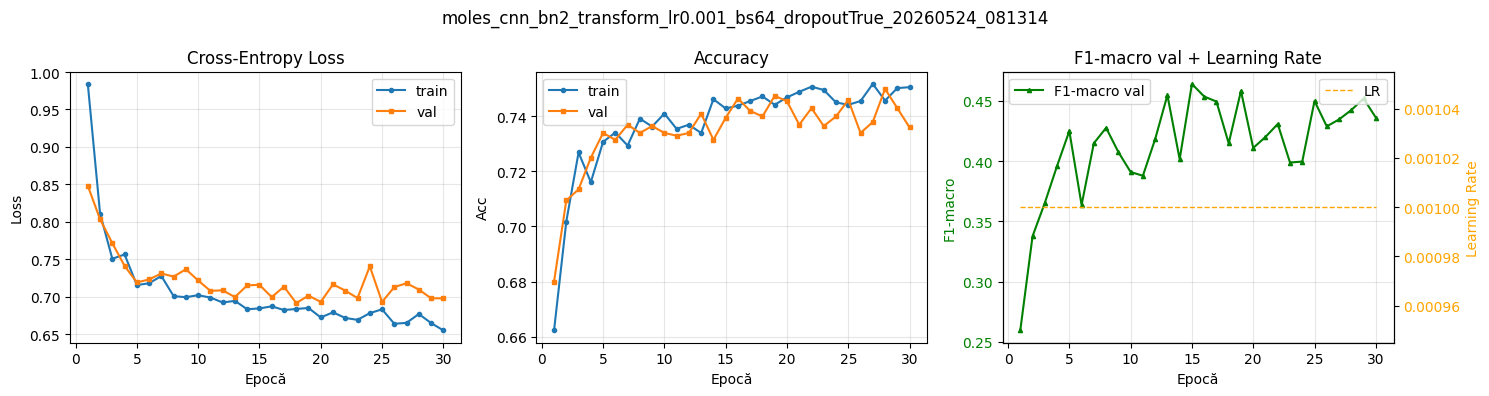

Graficele salvate în moles_cnn_bn2_transform_lr0.001_bs64_dropoutTrue_20260524_081314_curves.png


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

def plot_confusion_matrix(all_labels, all_preds, class_names, title="Matrice de confuzie"):
    """
    Plotează matricea de confuzie normalizată (procente pe rând).
    Normalizarea pe rând arată recall-ul per clasă.
    """
    cm = confusion_matrix(all_labels, all_preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # normalizare pe rând

    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(cm_norm, interpolation="nearest", cmap="Blues")
    plt.colorbar(im, ax=ax)

    ax.set_xticks(range(len(class_names)))
    ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticklabels(class_names)
    ax.set_xlabel("Predicție")
    ax.set_ylabel("Etichetă reală")
    ax.set_title(title)

    # Scriem procentele în celule
    thresh = cm_norm.max() / 2.0
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            ax.text(j, i, f"{cm_norm[i, j]:.2f}",
                    ha="center", va="center",
                    color="white" if cm_norm[i, j] > thresh else "black",
                    fontsize=8)
    plt.tight_layout()
    plt.show()
    return cm

def plot_history(history, run_name="experiment"):
    """
    Afișează 3 grafice:
    1. Curba de Loss (train vs val)
    2. Curba de Accuracy (train vs val)
    3. Curba de F1-macro (val) + Learning Rate

    Cum interpretăm:
    - OVERFITTING: train loss scade continuu, val loss crește → prea multă complexitate
    - UNDERFITTING: ambele curbe sunt ridicate și stagnează → model prea simplu / lr prea mic
    - IDEAL: ambele curbe scad și se apropie
    """
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(run_name, fontsize=12)

    # Grafic 1: Loss
    axes[0].plot(epochs, history["train_loss"], label="train", marker="o", markersize=3)
    axes[0].plot(epochs, history["val_loss"],   label="val",   marker="s", markersize=3)
    axes[0].set_title("Cross-Entropy Loss")
    axes[0].set_xlabel("Epocă")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Grafic 2: Accuracy
    axes[1].plot(epochs, history["train_acc"], label="train", marker="o", markersize=3)
    axes[1].plot(epochs, history["val_acc"],   label="val",   marker="s", markersize=3)
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epocă")
    axes[1].set_ylabel("Acc")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    # Grafic 3: F1-macro + LR
    ax3 = axes[2]
    ax3.plot(epochs, history["val_f1_macro"], color="green", label="F1-macro val",
             marker="^", markersize=3)
    ax3.set_title("F1-macro val + Learning Rate")
    ax3.set_xlabel("Epocă")
    ax3.set_ylabel("F1-macro", color="green")
    ax3.tick_params(axis="y", labelcolor="green")
    ax3.legend(loc="upper left")
    ax3.grid(alpha=0.3)

    if history["lr"]:
        ax3b = ax3.twinx()
        ax3b.plot(epochs, history["lr"], color="orange",
                  linestyle="--", label="LR", linewidth=1)
        ax3b.set_ylabel("Learning Rate", color="orange")
        ax3b.tick_params(axis="y", labelcolor="orange")
        ax3b.legend(loc="upper right")

    plt.tight_layout()
    plt.savefig(f"{run_name}_curves.png", dpi=150)
    plt.show()
    print(f"Graficele salvate în {run_name}_curves.png")

def plot_f1_per_class(history, class_names, run_name="experiment"):
    """
    Plotează evoluția F1-score per clasă pe parcursul antrenării.
    """
    if not history or not history.get("f1_per_class"):
        print("Nu există date de F1 per clasă în istoric.")
        return

    epochs = range(1, len(history["f1_per_class"]) + 1)

    # Convertim lista de array-uri de F1 în array-uri per clasă
    f1_scores_per_class = np.array(history["f1_per_class"]).T # Transpunem

    plt.figure(figsize=(10, 6))
    for i, class_name in enumerate(class_names):
        plt.plot(epochs, f1_scores_per_class[i], label=f"F1 {class_name}", marker='o', markersize=3)

    plt.title(f"Evoluția F1-score per clasă ({run_name})")
    plt.xlabel("Epocă")
    plt.ylabel("F1-score")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{run_name}_f1_per_class.png", dpi=150)
    plt.show()
    print(f"Graficele F1 per clasă salvate în {run_name}_f1_per_class.png")

NUM_EPOCHS = 30
best_val_loss = float("inf")
os.makedirs("checkpoints", exist_ok=True)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_moles_cnn_bn2_transform.parameters(), lr=LR, weight_decay=1e-4)

# ── Numele claselor ───────────────────────────────────────────────────────────
class_names = MOLES_CLASSES # Folosim MOLES_CLASSES pentru moles dataset

history = {
    "train_loss": [], "train_acc": [],
    "val_loss":   [], "val_acc":   [],
    "val_f1_macro": [], "val_f1_micro": [],
    "f1_per_class": [],   # ← nou
    "lr": []
}

# ─── Logăm un batch de imagini la pasul 0 ────────────────────────────────────
images, labels = next(iter(train_loader_moles_new))
grid = torchvision.utils.make_grid(images[:16], nrow=4, normalize=True)
writer.add_image("Train/sample_batch", grid, global_step=0)

for epoch in range(NUM_EPOCHS):
    # ── Antrenare ─────────────────────────────────────────────────────────────
    tr_loss, tr_acc = train_one_epoch(model_moles_cnn_bn2_transform, train_loader_moles_new, criterion, optimizer, device)

    # ── Evaluare ──────────────────────────────────────────────────────────────
    va_loss, va_acc, va_f1_mac, va_f1_mic, all_labels, all_preds = evaluate(
        model_moles_cnn_bn2_transform, val_loader_moles_new, criterion, device
    )

    # ── F1 per clasă ──────────────────────────────────────────────────────────
    f1_per_class = f1_score(all_labels, all_preds, average=None, zero_division=0)
    history["f1_per_class"].append(f1_per_class)

    # ── Scheduler ─────────────────────────────────────────────────────────────
    # scheduler.step(va_loss)

    # ── Salvarea celui mai bun model ──────────────────────────────────────────
    if va_loss < best_val_loss:
        best_val_loss = va_loss
        torch.save(model_moles_cnn_bn2_transform.state_dict(), f"checkpoints/{RUN_NAME}_best.pt")

        # ── Classification report doar când avem best model ───────────────────
        print("\n── Best model! Classification Report ──────────────────────────")
        print(classification_report(all_labels, all_preds,
                                    target_names=class_names, zero_division=0))

    # ── Logging TensorBoard ───────────────────────────────────────────────────
    writer.add_scalar("Loss/train",   tr_loss,   epoch)
    writer.add_scalar("Loss/val",     va_loss,   epoch)
    writer.add_scalar("Acc/train",    tr_acc,    epoch)
    writer.add_scalar("Acc/val",      va_acc,    epoch)
    writer.add_scalar("F1_macro/val", va_f1_mac, epoch)
    writer.add_scalar("F1_micro/val", va_f1_mic, epoch)
    for i, (name, f1) in enumerate(zip(class_names, f1_per_class)):
        writer.add_scalar(f"F1_per_class/{name}", f1, epoch)  # ← grafic separat per clasă
    current_lr = optimizer.param_groups[0]["lr"]
    writer.add_scalar("LR", current_lr, epoch)

    # ── Afișare terminal ──────────────────────────────────────────────────────
    print(f"Epocă {epoch+1:02d}/{NUM_EPOCHS} | "
          f"train loss={tr_loss:.4f} acc={tr_acc:.3f} | "
          f"val loss={va_loss:.4f} acc={va_acc:.3f} "
          f"F1mac={va_f1_mac:.3f} F1mic={va_f1_mic:.3f} "
          f"lr={current_lr:.6f}")
    # F1 per clasă inline
    f1_str = " | ".join(f"{n}={f:.2f}" for n, f in zip(class_names, f1_per_class))
    print(f"  F1/clasă: {f1_str}")

    # ── History ───────────────────────────────────────────────────────────────
    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["val_loss"].append(va_loss)
    history["val_acc"].append(va_acc)
    history["val_f1_macro"].append(va_f1_mac)
    history["val_f1_micro"].append(va_f1_mic)
    history["lr"].append(current_lr)

# ─── Închide TensorBoard ──────────────────────────────────────────────────────
writer.close()
print("Antrenarea s-a terminat!")

# ─── Confusion matrix finală (pe ultimul epoch) ───────────────────────────────
plot_confusion_matrix(all_labels, all_preds, class_names)

# ─── F1 per clasă în timp ─────────────────────────────────────────────────────
plot_f1_per_class(history, class_names, run_name=RUN_NAME)

# ─── Grafice loss/acc/f1 ──────────────────────────────────────────────────────
plot_history(history, run_name=RUN_NAME)

In [ ]:
LR = 1e-3
BATCH_SIZE = 64
# ── Configurarea numelui experimentului ──────────────────────────────────────
# Numele trebuie să fie descriptiv — va apărea ca o curbă separată în TensorBoard!
# Schimbă 'mlp' cu 'cnn' / 'resnet18' etc. când rulezi alte modele.
RUN_NAME = (
    f"faces_cnn_bn2_transform"
    f"_lr{LR}"
    f"_bs{BATCH_SIZE}"
    f"_dropout{True}"
    f"_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
)
print(f"Experiment: {RUN_NAME}")

writer = SummaryWriter(log_dir=f"runs/{RUN_NAME}")

Experiment: faces_cnn_bn2_transform_lr0.001_bs64_dropoutTrue_20260524_082314



── Best model! Classification Report ──────────────────────────
              precision    recall  f1-score   support

    Surprise       0.60      0.48      0.53       416
        Fear       0.00      0.00      0.00         0
     Disgust       0.14      0.37      0.20        59
   Happiness       0.77      0.78      0.77      1168
     Sadness       0.37      0.43      0.40       413
       Anger       0.43      0.36      0.39       194
     Neutral       0.57      0.48      0.52       818

    accuracy                           0.57      3068
   macro avg       0.41      0.41      0.40      3068
weighted avg       0.61      0.57      0.59      3068

Epocă 01/30 | train loss=1.4179 acc=0.478 | val loss=1.1622 acc=0.575 F1mac=0.401 F1mic=0.575 lr=0.001000
  F1/clasă: Surprise=0.53 | Fear=0.00 | Disgust=0.20 | Happiness=0.77 | Sadness=0.40 | Anger=0.39 | Neutral=0.52

── Best model! Classification Report ──────────────────────────
              precision    recall  f1-score   support


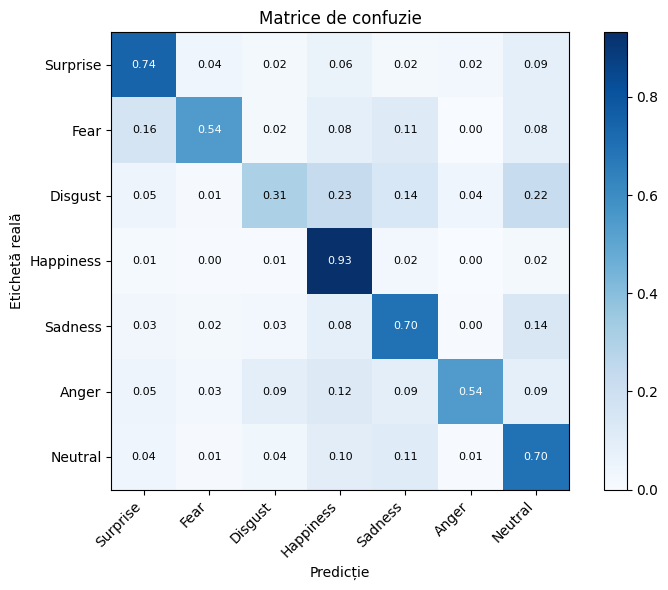

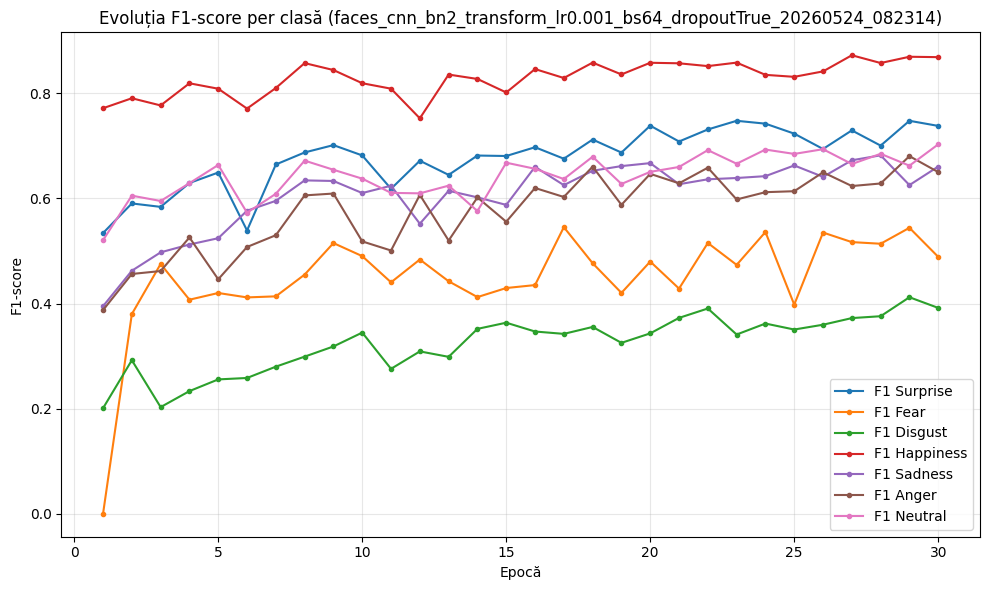

Graficele F1 per clasă salvate în faces_cnn_bn2_transform_lr0.001_bs64_dropoutTrue_20260524_082314_f1_per_class.png


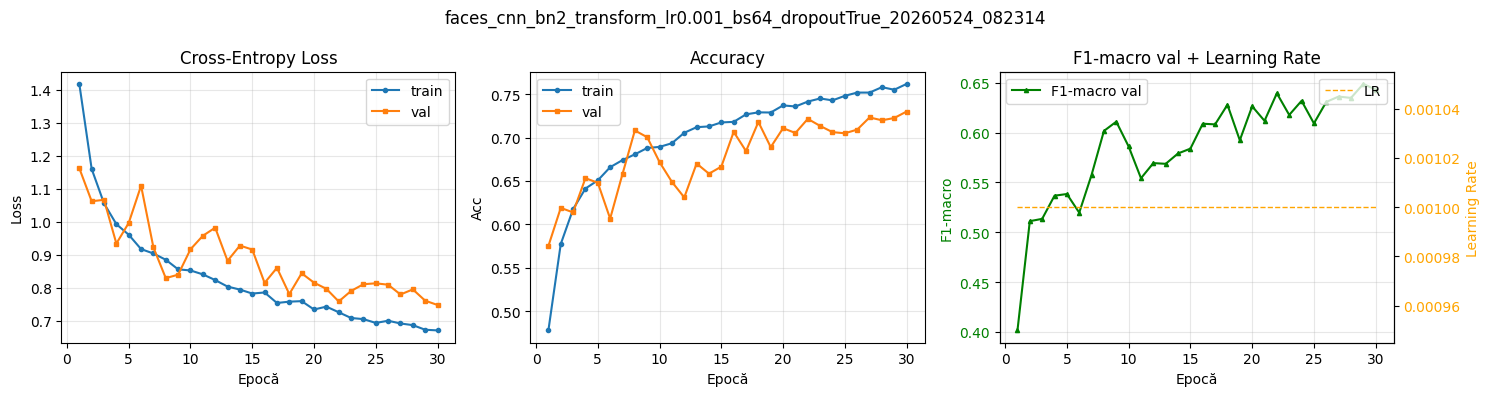

Graficele salvate în faces_cnn_bn2_transform_lr0.001_bs64_dropoutTrue_20260524_082314_curves.png


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

def plot_confusion_matrix(all_labels, all_preds, class_names, title="Matrice de confuzie"):
    """
    Plotează matricea de confuzie normalizată (procente pe rând).
    Normalizarea pe rând arată recall-ul per clasă.
    """
    cm = confusion_matrix(all_labels, all_preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # normalizare pe rând

    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(cm_norm, interpolation="nearest", cmap="Blues")
    plt.colorbar(im, ax=ax)

    ax.set_xticks(range(len(class_names)))
    ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticklabels(class_names)
    ax.set_xlabel("Predicție")
    ax.set_ylabel("Etichetă reală")
    ax.set_title(title)

    # Scriem procentele în celule
    thresh = cm_norm.max() / 2.0
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            ax.text(j, i, f"{cm_norm[i, j]:.2f}",
                    ha="center", va="center",
                    color="white" if cm_norm[i, j] > thresh else "black",
                    fontsize=8)
    plt.tight_layout()
    plt.show()
    return cm

def plot_history(history, run_name="experiment"):
    """
    Afișează 3 grafice:
    1. Curba de Loss (train vs val)
    2. Curba de Accuracy (train vs val)
    3. Curba de F1-macro (val) + Learning Rate

    Cum interpretăm:
    - OVERFITTING: train loss scade continuu, val loss crește → prea multă complexitate
    - UNDERFITTING: ambele curbe sunt ridicate și stagnează → model prea simplu / lr prea mic
    - IDEAL: ambele curbe scad și se apropie
    """
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(run_name, fontsize=12)

    # Grafic 1: Loss
    axes[0].plot(epochs, history["train_loss"], label="train", marker="o", markersize=3)
    axes[0].plot(epochs, history["val_loss"],   label="val",   marker="s", markersize=3)
    axes[0].set_title("Cross-Entropy Loss")
    axes[0].set_xlabel("Epocă")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Grafic 2: Accuracy
    axes[1].plot(epochs, history["train_acc"], label="train", marker="o", markersize=3)
    axes[1].plot(epochs, history["val_acc"],   label="val",   marker="s", markersize=3)
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epocă")
    axes[1].set_ylabel("Acc")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    # Grafic 3: F1-macro + LR
    ax3 = axes[2]
    ax3.plot(epochs, history["val_f1_macro"], color="green", label="F1-macro val",
             marker="^", markersize=3)
    ax3.set_title("F1-macro val + Learning Rate")
    ax3.set_xlabel("Epocă")
    ax3.set_ylabel("F1-macro", color="green")
    ax3.tick_params(axis="y", labelcolor="green")
    ax3.legend(loc="upper left")
    ax3.grid(alpha=0.3)

    if history["lr"]:
        ax3b = ax3.twinx()
        ax3b.plot(epochs, history["lr"], color="orange",
                  linestyle="--", label="LR", linewidth=1)
        ax3b.set_ylabel("Learning Rate", color="orange")
        ax3b.tick_params(axis="y", labelcolor="orange")
        ax3b.legend(loc="upper right")

    plt.tight_layout()
    plt.savefig(f"{run_name}_curves.png", dpi=150)
    plt.show()
    print(f"Graficele salvate în {run_name}_curves.png")

def plot_f1_per_class(history, class_names, run_name="experiment"):
    """
    Plotează evoluția F1-score per clasă pe parcursul antrenării.
    """
    if not history or not history.get("f1_per_class"):
        print("Nu există date de F1 per clasă în istoric.")
        return

    epochs = range(1, len(history["f1_per_class"]) + 1)

    # Convertim lista de array-uri de F1 în array-uri per clasă
    f1_scores_per_class = np.array(history["f1_per_class"]).T # Transpunem

    plt.figure(figsize=(10, 6))
    for i, class_name in enumerate(class_names):
        plt.plot(epochs, f1_scores_per_class[i], label=f"F1 {class_name}", marker='o', markersize=3)

    plt.title(f"Evoluția F1-score per clasă ({run_name})")
    plt.xlabel("Epocă")
    plt.ylabel("F1-score")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{run_name}_f1_per_class.png", dpi=150)
    plt.show()
    print(f"Graficele F1 per clasă salvate în {run_name}_f1_per_class.png")

NUM_EPOCHS = 30
best_val_loss = float("inf")
os.makedirs("checkpoints", exist_ok=True)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_faces_cnn_bn2_transform.parameters(), lr=LR, weight_decay=1e-4)

# ── Numele claselor ───────────────────────────────────────────────────────────
class_names = FACE_CLASSES # Folosim MOLES_CLASSES pentru moles dataset

history = {
    "train_loss": [], "train_acc": [],
    "val_loss":   [], "val_acc":   [],
    "val_f1_macro": [], "val_f1_micro": [],
    "f1_per_class": [],   # ← nou
    "lr": []
}

# ─── Logăm un batch de imagini la pasul 0 ────────────────────────────────────
images, labels = next(iter(train_loader_faces_new))
grid = torchvision.utils.make_grid(images[:16], nrow=4, normalize=True)
writer.add_image("Train/sample_batch", grid, global_step=0)

for epoch in range(NUM_EPOCHS):
    # ── Antrenare ─────────────────────────────────────────────────────────────
    tr_loss, tr_acc = train_one_epoch(model_faces_cnn_bn2_transform, train_loader_faces_new, criterion, optimizer, device)

    # ── Evaluare ──────────────────────────────────────────────────────────────
    va_loss, va_acc, va_f1_mac, va_f1_mic, all_labels, all_preds = evaluate(
        model_faces_cnn_bn2_transform, val_loader_faces_new, criterion, device
    )

    # ── F1 per clasă ──────────────────────────────────────────────────────────
    f1_per_class = f1_score(all_labels, all_preds, average=None, zero_division=0)
    history["f1_per_class"].append(f1_per_class)

    # ── Scheduler ─────────────────────────────────────────────────────────────
    # scheduler.step(va_loss)

    # ── Salvarea celui mai bun model ──────────────────────────────────────────
    if va_loss < best_val_loss:
        best_val_loss = va_loss
        torch.save(model_faces_cnn_bn2_transform.state_dict(), f"checkpoints/{RUN_NAME}_best.pt")

        # ── Classification report doar când avem best model ───────────────────
        print("\n── Best model! Classification Report ──────────────────────────")
        print(classification_report(all_labels, all_preds,
                                    target_names=class_names, zero_division=0))

    # ── Logging TensorBoard ───────────────────────────────────────────────────
    writer.add_scalar("Loss/train",   tr_loss,   epoch)
    writer.add_scalar("Loss/val",     va_loss,   epoch)
    writer.add_scalar("Acc/train",    tr_acc,    epoch)
    writer.add_scalar("Acc/val",      va_acc,    epoch)
    writer.add_scalar("F1_macro/val", va_f1_mac, epoch)
    writer.add_scalar("F1_micro/val", va_f1_mic, epoch)
    for i, (name, f1) in enumerate(zip(class_names, f1_per_class)):
        writer.add_scalar(f"F1_per_class/{name}", f1, epoch)  # ← grafic separat per clasă
    current_lr = optimizer.param_groups[0]["lr"]
    writer.add_scalar("LR", current_lr, epoch)

    # ── Afișare terminal ──────────────────────────────────────────────────────
    print(f"Epocă {epoch+1:02d}/{NUM_EPOCHS} | "
          f"train loss={tr_loss:.4f} acc={tr_acc:.3f} | "
          f"val loss={va_loss:.4f} acc={va_acc:.3f} "
          f"F1mac={va_f1_mac:.3f} F1mic={va_f1_mic:.3f} "
          f"lr={current_lr:.6f}")
    # F1 per clasă inline
    f1_str = " | ".join(f"{n}={f:.2f}" for n, f in zip(class_names, f1_per_class))
    print(f"  F1/clasă: {f1_str}")

    # ── History ───────────────────────────────────────────────────────────────
    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["val_loss"].append(va_loss)
    history["val_acc"].append(va_acc)
    history["val_f1_macro"].append(va_f1_mac)
    history["val_f1_micro"].append(va_f1_mic)
    history["lr"].append(current_lr)

# ─── Închide TensorBoard ──────────────────────────────────────────────────────
writer.close()
print("Antrenarea s-a terminat!")

# ─── Confusion matrix finală (pe ultimul epoch) ───────────────────────────────
plot_confusion_matrix(all_labels, all_preds, class_names)

# ─── F1 per clasă în timp ─────────────────────────────────────────────────────
plot_f1_per_class(history, class_names, run_name=RUN_NAME)

# ─── Grafice loss/acc/f1 ──────────────────────────────────────────────────────
plot_history(history, run_name=RUN_NAME)

### Visualizing Augmented Data

Below are examples of images from the moles and faces datasets after data augmentation has been applied. This helps verify that the transformations are working as expected and generating diverse training samples.

Displaying a batch of augmented moles images:


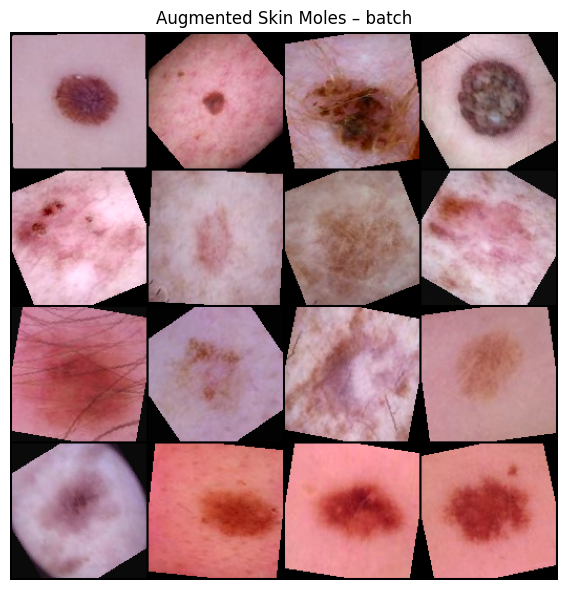

Etichete: [5, 5, 5, 5, 0, 3, 2, 2, 5, 2, 0, 2, 5, 5, 5, 5]


In [ ]:
print('Displaying a batch of augmented moles images:')
show_batch(train_loader_moles_new, MOLES_MEAN, MOLES_STD, title="Augmented Skin Moles – batch")

Displaying a batch of augmented faces images:


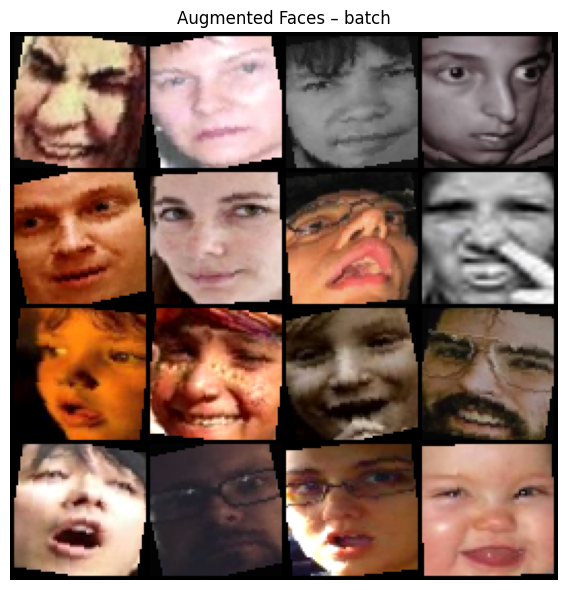

Etichete: [3, 6, 6, 0, 0, 3, 0, 2, 0, 3, 3, 3, 0, 6, 0, 3]


In [ ]:
print('Displaying a batch of augmented faces images:')
show_batch(train_loader_faces_new, FACE_MEAN, FACE_STD, title="Augmented Faces – batch")

In [ ]:
import numpy as np
from torch.utils.data import WeightedRandomSampler

# Get labels from the new moles training dataset
# Ensure train_set_moles_new is defined from a previous cell (e.g., cell 0d0d2f9d)
if 'train_set_moles_new' not in locals():
    raise NameError("train_set_moles_new is not defined. Please run cell 0d0d2f9d first.")

# Extract labels from the dataset samples
labels = np.array([label for _, label in train_set_moles_new.samples])

# Count occurrences of each class
class_counts = np.bincount(labels)
print(f"Original class distribution: {class_counts}")

# Calculate class weights inversely proportional to their frequency
# Add a small epsilon to avoid division by zero for classes that might not be present (though unlikely here)
class_weights = 1.0 / (class_counts + 1e-6)

# Create sample weights for each example in the training set
sample_weights = class_weights[labels]

# Initialize WeightedRandomSampler
# replacement=True means samples from rare classes can be picked multiple times (oversampling)
sampler_moles = WeightedRandomSampler(
    weights=torch.from_numpy(sample_weights).double(),
    num_samples=len(sample_weights),
    replacement=True
)

# Re-define train_loader_moles_new to use the sampler
# IMPORTANT: When using a sampler, DO NOT set shuffle=True
train_loader_moles_balanced = DataLoader(train_set_moles_new, batch_size=BATCH_SIZE,
                                        sampler=sampler_moles, num_workers=2, drop_last=True)

print(f"Train loader for moles updated with WeightedRandomSampler. Effective training samples per epoch: {len(train_loader_moles_balanced) * BATCH_SIZE}")

# Define class weights for CrossEntropyLoss
# Formula: w_c = N_total / (num_classes * N_c)
# Convert class_counts to a PyTorch tensor and move to device
counts_tensor = torch.tensor(class_counts, dtype=torch.float).to(device)
weights_for_loss = counts_tensor.sum() / (len(counts_tensor) * counts_tensor)

# Re-initialize criterion with class weights
criterion_weighted = nn.CrossEntropyLoss(weight=weights_for_loss)

print(f"CrossEntropyLoss re-initialized with class weights: {weights_for_loss}")


Original class distribution: [ 196  308  660   69  668 4023   85]
Train loader for moles updated with WeightedRandomSampler. Effective training samples per epoch: 5952
CrossEntropyLoss re-initialized with class weights: tensor([ 4.3797,  2.7871,  1.3006, 12.4410,  1.2851,  0.2134, 10.0992],
       device='cuda:0')


The code above addresses class imbalance in the 'moles' dataset by:

1.  **Calculating Class Weights**: It determines the frequency of each class in the `train_set_moles_new` and calculates inverse weights. This means rarer classes get higher weights.
2.  **`WeightedRandomSampler`**: A `WeightedRandomSampler` is created using these sample-specific weights. This sampler ensures that during training, examples from under-represented classes are sampled more frequently (oversampling), balancing the batches.
3.  **Updated DataLoader**: The `train_loader_moles_new` is re-initialized as `train_loader_moles_balanced` to use this custom sampler. Note that `shuffle=True` is explicitly removed when using a sampler.
4.  **Weighted Cross-Entropy Loss**: A new `criterion_weighted` is defined using `nn.CrossEntropyLoss` with the calculated `weights_for_loss`. This penalizes misclassifications of minority classes more heavily, making the model pay more attention to them.

To use these changes, you will need to update your training loop to use `train_loader_moles_balanced` and `criterion_weighted`.

In [ ]:
model_moles_cnn_bn2_transform_balanced = CNN_cu_BatchNorm2d(
    input_channels=3,
    img_height=128,
    img_width=128,
    num_classes=7,
    use_dropout=True,
).to(device)

n_params = sum(p.numel() for p in model_moles_cnn_bn2_transform_balanced.parameters() if p.requires_grad)
print(f"SimpleCNN_cu_BatchNorm2d_transform – parametri antrenabili: {n_params:,}")
print(model_moles_cnn_bn2_transform_balanced)

SimpleCNN_cu_BatchNorm2d_transform – parametri antrenabili: 33,579,143
CNN_cu_BatchNorm2d(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=65536, out_features=512, bias=True)
    (2): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ReLU(inplace=True)
    (4): Dropout(p=0.5, inplace=False)
    (5): Linear(in_features=512, out_

In [ ]:
LR = 1e-3
BATCH_SIZE = 64
# ── Configurarea numelui experimentului ──────────────────────────────────────
# Numele trebuie să fie descriptiv — va apărea ca o curbă separată în TensorBoard!
# Schimbă 'mlp' cu 'cnn' / 'resnet18' etc. când rulezi alte modele.
RUN_NAME = (
    f"moles_cnn_bn2_transform_balanced"
    f"_lr{LR}"
    f"_bs{BATCH_SIZE}"
    f"_dropout{True}"
    f"_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
)
print(f"Experiment: {RUN_NAME}")

writer = SummaryWriter(log_dir=f"runs/{RUN_NAME}")

Experiment: moles_cnn_bn2_transform_balanced_lr0.001_bs64_dropoutTrue_20260524_155403



── Best model! Classification Report ──────────────────────────
              precision    recall  f1-score   support

       akiec       0.22      0.54      0.32        65
         bcc       0.30      0.34      0.32       103
         bkl       0.33      0.33      0.33       220
          df       0.08      0.35      0.13        23
         mel       0.27      0.52      0.35       222
          nv       0.95      0.56      0.71      1341
        vasc       0.13      0.83      0.23        29

    accuracy                           0.52      2003
   macro avg       0.33      0.50      0.34      2003
weighted avg       0.73      0.52      0.58      2003

Epocă 01/30 | train loss=1.4393 acc=0.453 | val loss=1.2637 acc=0.521 F1mac=0.340 F1mic=0.521 lr=0.001000
  F1/clasă: akiec=0.32 | bcc=0.32 | bkl=0.33 | df=0.13 | mel=0.35 | nv=0.71 | vasc=0.23

── Best model! Classification Report ──────────────────────────
              precision    recall  f1-score   support

       akiec       0.26 

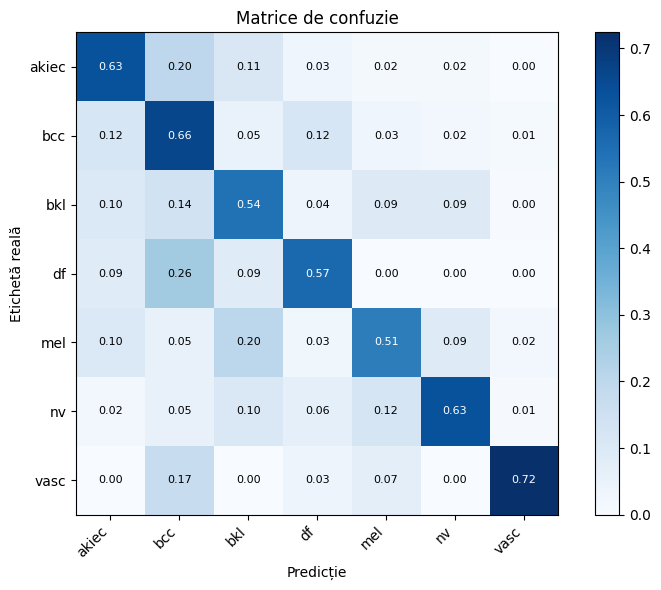

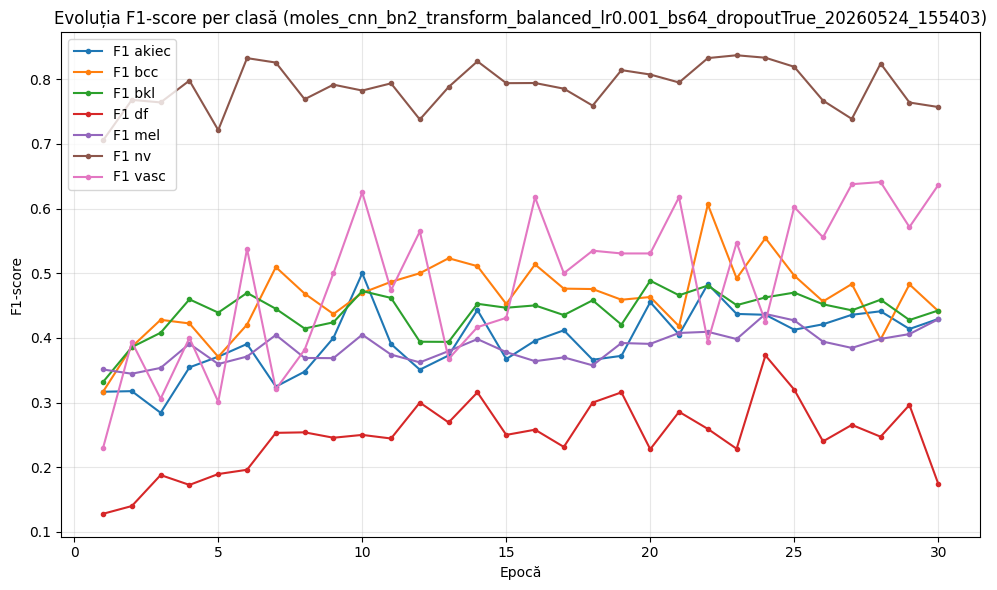

Graficele F1 per clasă salvate în moles_cnn_bn2_transform_balanced_lr0.001_bs64_dropoutTrue_20260524_155403_f1_per_class.png


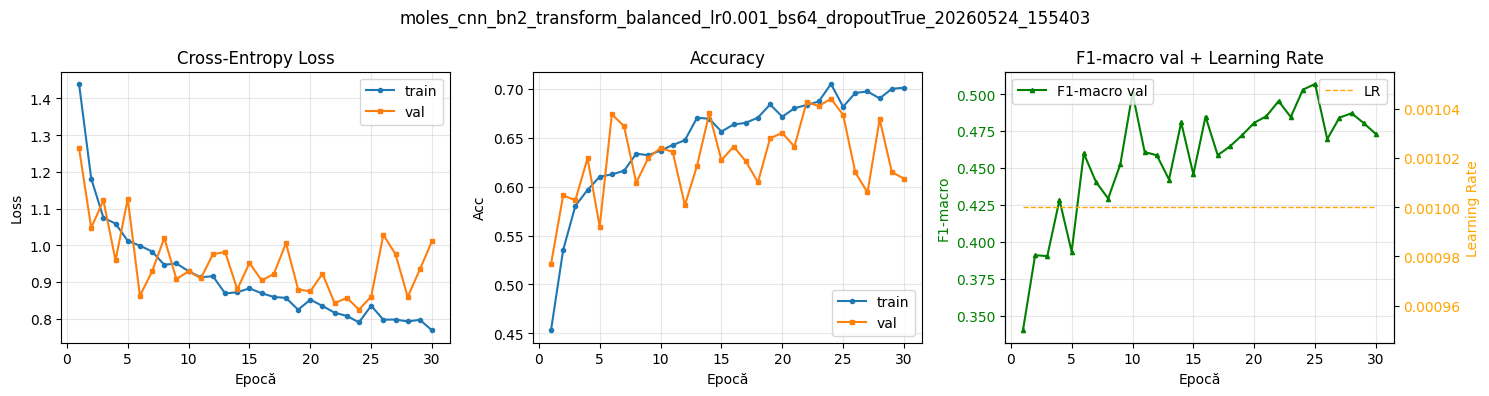

Graficele salvate în moles_cnn_bn2_transform_balanced_lr0.001_bs64_dropoutTrue_20260524_155403_curves.png


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

def plot_confusion_matrix(all_labels, all_preds, class_names, title="Matrice de confuzie"):
    """
    Plotează matricea de confuzie normalizată (procente pe rând).
    Normalizarea pe rând arată recall-ul per clasă.
    """
    cm = confusion_matrix(all_labels, all_preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # normalizare pe rând

    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(cm_norm, interpolation="nearest", cmap="Blues")
    plt.colorbar(im, ax=ax)

    ax.set_xticks(range(len(class_names)))
    ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticklabels(class_names)
    ax.set_xlabel("Predicție")
    ax.set_ylabel("Etichetă reală")
    ax.set_title(title)

    # Scriem procentele în celule
    thresh = cm_norm.max() / 2.0
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            ax.text(j, i, f"{cm_norm[i, j]:.2f}",
                    ha="center", va="center",
                    color="white" if cm_norm[i, j] > thresh else "black",
                    fontsize=8)
    plt.tight_layout()
    plt.show()
    return cm

def plot_history(history, run_name="experiment"):
    """
    Afișează 3 grafice:
    1. Curba de Loss (train vs val)
    2. Curba de Accuracy (train vs val)
    3. Curba de F1-macro (val) + Learning Rate

    Cum interpretăm:
    - OVERFITTING: train loss scade continuu, val loss crește → prea multă complexitate
    - UNDERFITTING: ambele curbe sunt ridicate și stagnează → model prea simplu / lr prea mic
    - IDEAL: ambele curbe scad și se apropie
    """
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(run_name, fontsize=12)

    # Grafic 1: Loss
    axes[0].plot(epochs, history["train_loss"], label="train", marker="o", markersize=3)
    axes[0].plot(epochs, history["val_loss"],   label="val",   marker="s", markersize=3)
    axes[0].set_title("Cross-Entropy Loss")
    axes[0].set_xlabel("Epocă")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Grafic 2: Accuracy
    axes[1].plot(epochs, history["train_acc"], label="train", marker="o", markersize=3)
    axes[1].plot(epochs, history["val_acc"],   label="val",   marker="s", markersize=3)
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epocă")
    axes[1].set_ylabel("Acc")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    # Grafic 3: F1-macro + LR
    ax3 = axes[2]
    ax3.plot(epochs, history["val_f1_macro"], color="green", label="F1-macro val",
             marker="^", markersize=3)
    ax3.set_title("F1-macro val + Learning Rate")
    ax3.set_xlabel("Epocă")
    ax3.set_ylabel("F1-macro", color="green")
    ax3.tick_params(axis="y", labelcolor="green")
    ax3.legend(loc="upper left")
    ax3.grid(alpha=0.3)

    if history["lr"]:
        ax3b = ax3.twinx()
        ax3b.plot(epochs, history["lr"], color="orange",
                  linestyle="--", label="LR", linewidth=1)
        ax3b.set_ylabel("Learning Rate", color="orange")
        ax3b.tick_params(axis="y", labelcolor="orange")
        ax3b.legend(loc="upper right")

    plt.tight_layout()
    plt.savefig(f"{run_name}_curves.png", dpi=150)
    plt.show()
    print(f"Graficele salvate în {run_name}_curves.png")

def plot_f1_per_class(history, class_names, run_name="experiment"):
    """
    Plotează evoluția F1-score per clasă pe parcursul antrenării.
    """
    if not history or not history.get("f1_per_class"):
        print("Nu există date de F1 per clasă în istoric.")
        return

    epochs = range(1, len(history["f1_per_class"]) + 1)

    # Convertim lista de array-uri de F1 în array-uri per clasă
    f1_scores_per_class = np.array(history["f1_per_class"]).T # Transpunem

    plt.figure(figsize=(10, 6))
    for i, class_name in enumerate(class_names):
        plt.plot(epochs, f1_scores_per_class[i], label=f"F1 {class_name}", marker='o', markersize=3)

    plt.title(f"Evoluția F1-score per clasă ({run_name})")
    plt.xlabel("Epocă")
    plt.ylabel("F1-score")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{run_name}_f1_per_class.png", dpi=150)
    plt.show()
    print(f"Graficele F1 per clasă salvate în {run_name}_f1_per_class.png")

NUM_EPOCHS = 30
best_val_loss = float("inf")
os.makedirs("checkpoints", exist_ok=True)

optimizer = optim.Adam(model_moles_cnn_bn2_transform_balanced.parameters(), lr=LR, weight_decay=1e-4)

# ── Numele claselor ───────────────────────────────────────────────────────────
class_names = MOLES_CLASSES # Folosim MOLES_CLASSES pentru moles dataset

history = {
    "train_loss": [], "train_acc": [],
    "val_loss":   [], "val_acc":   [],
    "val_f1_macro": [], "val_f1_micro": [],
    "f1_per_class": [],   # ← nou
    "lr": []
}

# ─── Logăm un batch de imagini la pasul 0 ────────────────────────────────────
images, labels = next(iter(train_loader_moles_new))
grid = torchvision.utils.make_grid(images[:16], nrow=4, normalize=True)
writer.add_image("Train/sample_batch", grid, global_step=0)

for epoch in range(NUM_EPOCHS):
    # ── Antrenare ─────────────────────────────────────────────────────────────
    tr_loss, tr_acc = train_one_epoch(model_moles_cnn_bn2_transform_balanced, train_loader_moles_balanced, criterion, optimizer, device)

    # ── Evaluare ──────────────────────────────────────────────────────────────
    va_loss, va_acc, va_f1_mac, va_f1_mic, all_labels, all_preds = evaluate(
        model_moles_cnn_bn2_transform_balanced, val_loader_moles_new, criterion, device
    )

    # ── F1 per clasă ──────────────────────────────────────────────────────────
    f1_per_class = f1_score(all_labels, all_preds, average=None, zero_division=0)
    history["f1_per_class"].append(f1_per_class)

    # ── Scheduler ─────────────────────────────────────────────────────────────
    # scheduler.step(va_loss)

    # ── Salvarea celui mai bun model ──────────────────────────────────────────
    if va_loss < best_val_loss:
        best_val_loss = va_loss
        torch.save(model_moles_cnn_bn2_transform_balanced.state_dict(), f"checkpoints/{RUN_NAME}_best.pt")

        # ── Classification report doar când avem best model ───────────────────
        print("\n── Best model! Classification Report ──────────────────────────")
        print(classification_report(all_labels, all_preds,
                                    target_names=class_names, zero_division=0))

    # ── Logging TensorBoard ───────────────────────────────────────────────────
    writer.add_scalar("Loss/train",   tr_loss,   epoch)
    writer.add_scalar("Loss/val",     va_loss,   epoch)
    writer.add_scalar("Acc/train",    tr_acc,    epoch)
    writer.add_scalar("Acc/val",      va_acc,    epoch)
    writer.add_scalar("F1_macro/val", va_f1_mac, epoch)
    writer.add_scalar("F1_micro/val", va_f1_mic, epoch)
    for i, (name, f1) in enumerate(zip(class_names, f1_per_class)):
        writer.add_scalar(f"F1_per_class/{name}", f1, epoch)  # ← grafic separat per clasă
    current_lr = optimizer.param_groups[0]["lr"]
    writer.add_scalar("LR", current_lr, epoch)

    # ── Afișare terminal ──────────────────────────────────────────────────────
    print(f"Epocă {epoch+1:02d}/{NUM_EPOCHS} | "
          f"train loss={tr_loss:.4f} acc={tr_acc:.3f} | "
          f"val loss={va_loss:.4f} acc={va_acc:.3f} "
          f"F1mac={va_f1_mac:.3f} F1mic={va_f1_mic:.3f} "
          f"lr={current_lr:.6f}")
    # F1 per clasă inline
    f1_str = " | ".join(f"{n}={f:.2f}" for n, f in zip(class_names, f1_per_class))
    print(f"  F1/clasă: {f1_str}")

    # ── History ───────────────────────────────────────────────────────────────
    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["val_loss"].append(va_loss)
    history["val_acc"].append(va_acc)
    history["val_f1_macro"].append(va_f1_mac)
    history["val_f1_micro"].append(va_f1_mic)
    history["lr"].append(current_lr)

# ─── Închide TensorBoard ──────────────────────────────────────────────────────
writer.close()
print("Antrenarea s-a terminat!")

# ─── Confusion matrix finală (pe ultimul epoch) ───────────────────────────────
plot_confusion_matrix(all_labels, all_preds, class_names)

# ─── F1 per clasă în timp ─────────────────────────────────────────────────────
plot_f1_per_class(history, class_names, run_name=RUN_NAME)

# ─── Grafice loss/acc/f1 ──────────────────────────────────────────────────────
plot_history(history, run_name=RUN_NAME)

In [16]:
import torchvision.models as models
import torch.nn as nn
# Incarcam un ResNet18 pre-antrenat pe ImageNet
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
# Modelul are pe ultimul strat 1000 clase (ImageNet). Trebuie sa il inlocuim
# cu un strat care are NUMARUL VOSTRU de clase (ex: 2 pentru clasificare binara).
num_classes = 7
in_features = model.fc.in_features # numarul de features inainte de stratul final
model.fc = nn.Linear(in_features, num_classes)
model = model.to(device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 72.2MB/s]


In [17]:
# Cazul 1: imaginile voastre sunt RGB dar la rezolutie mica (ex: 64x64).
# Solutia simpla: facem resize la 224x224 cu transforms.Resize.
# (Pentru CNN-uri pur convolutionale ati putea evita resize-ul, dar ResNet are
# un AdaptiveAvgPool care necesita o dimensiune minima, deci resize-ul e cel mai sigur.)
finetune_transform = transforms.Compose([
transforms.Resize((224, 224)), # adaptam dimensiunea
transforms.ToTensor(),
transforms.Normalize(mean=[0.485, 0.456, 0.406], # OBLIGATORIU statistici ImageNet
std=[0.229, 0.224, 0.225]), # daca modelul a fost antrenat asa
])


In [ ]:
# Ensure moles_train_transform and moles_val_transform are defined by running cell BWNpCvgh9mRQ first.

# Re-define datasets for moles using the new transformations
train_set_moles_new = ImageCSVDataset(
    "vai-de-pielea-mea/train.csv",
    root_dir="vai-de-pielea-mea/train",
    transform=finetune_transform,
    label_map=MOLES_LABEL_MAP,
)
val_set_moles_new = ImageCSVDataset(
    "vai-de-pielea-mea/test.csv",
    root_dir="vai-de-pielea-mea/test",
    transform=finetune_transform,
    label_map=MOLES_LABEL_MAP,
)

# Re-define dataloaders for moles
train_loader_moles_transform = DataLoader(train_set_moles_new, batch_size=BATCH_SIZE,
                                  shuffle=True, num_workers=2, drop_last=True)
val_loader_moles_transform = DataLoader(val_set_moles_new, batch_size=BATCH_SIZE,
                                shuffle=False, num_workers=2)

print(f"New Moles Train: {len(train_set_moles_new)} exemples, Val: {len(val_set_moles_new)} exemples")

# You should now use train_loader_moles_new and val_loader_moles_new in your training loop.

New Moles Train: 6009 exemples, Val: 2003 exemples


In [18]:
# Ensure faces_train_transform and faces_val_transform are defined by running cell NzVvULv49u5D first.

# Re-define datasets for faces using the new transformations
train_set_faces_new = ImageFolderDataset(
    "you-re-on-candid-camera/DATASET/train",
    transform=finetune_transform
)
val_set_faces_new = ImageFolderDataset(
    "you-re-on-candid-camera/DATASET/test",
    transform=finetune_transform
)

# Re-define dataloaders for faces
train_loader_faces_new = DataLoader(train_set_faces_new, batch_size=BATCH_SIZE,
                                  shuffle=True, num_workers=2, drop_last=True)
val_loader_faces_new = DataLoader(val_set_faces_new, batch_size=BATCH_SIZE,
                                shuffle=False, num_workers=2)

print(f"New Faces Train: {len(train_set_faces_new)} exemples, Val: {len(val_set_faces_new)} exemples")

# You should now use train_loader_faces_new and val_loader_faces_new in your training loop.

New Faces Train: 12271 exemples, Val: 3068 exemples


In [20]:
import torch.optim as optim
LR = 1e-3
# Strategia 2: "full fine-tuning" - antrenam toata reteaua, dar cu LR mai mic
# pentru straturile pre-antrenate.
# Util cand setul de date este mare sau foarte diferit de cel original.

# Toate straturile au requires_grad=True implicit la incarcare, dar sa fim siguri:
for param in model.parameters():
  param.requires_grad = True

# Definim grupuri de parametri pentru a aplica learning rate-uri diferite
optimizer = optim.Adam([
    {'params': model.fc.parameters(), 'lr': LR}, # Capul de clasificare
    {'params': [p for n, p in model.named_parameters() if 'fc' not in n], 'lr': LR * 0.1} # Backbone-ul (0.1x LR)
], lr=LR, weight_decay=1e-4)

In [21]:
LR = 1e-3
BATCH_SIZE = 64
# ── Configurarea numelui experimentului ──────────────────────────────────────
# Numele trebuie să fie descriptiv — va apărea ca o curbă separată în TensorBoard!
# Schimbă 'mlp' cu 'cnn' / 'resnet18' etc. când rulezi alte modele.
RUN_NAME = (
    f"faces_cnn_bn2_transform_finetune"
    f"_lr{LR}"
    f"_bs{BATCH_SIZE}"
    f"_dropout{True}"
    f"_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
)
print(f"Experiment: {RUN_NAME}")

writer = SummaryWriter(log_dir=f"runs/{RUN_NAME}")

Experiment: faces_cnn_bn2_transform_finetune_lr0.001_bs64_dropoutTrue_20260524_163541



── Best model! Classification Report ──────────────────────────
              precision    recall  f1-score   support

    Surprise       0.78      0.68      0.73       376
        Fear       0.32      0.73      0.45        33
     Disgust       0.05      0.33      0.09        24
   Happiness       0.89      0.78      0.83      1364
     Sadness       0.55      0.65      0.59       404
       Anger       0.46      0.72      0.56       103
     Neutral       0.70      0.62      0.66       764

    accuracy                           0.70      3068
   macro avg       0.54      0.64      0.56      3068
weighted avg       0.76      0.70      0.73      3068

Epocă 01/30 | train loss=1.1329 acc=0.590 | val loss=0.8305 acc=0.704 F1mac=0.558 F1mic=0.704 lr=0.000667
  F1/clasă: Surprise=0.73 | Fear=0.45 | Disgust=0.09 | Happiness=0.83 | Sadness=0.59 | Anger=0.56 | Neutral=0.66

── Best model! Classification Report ──────────────────────────
              precision    recall  f1-score   support


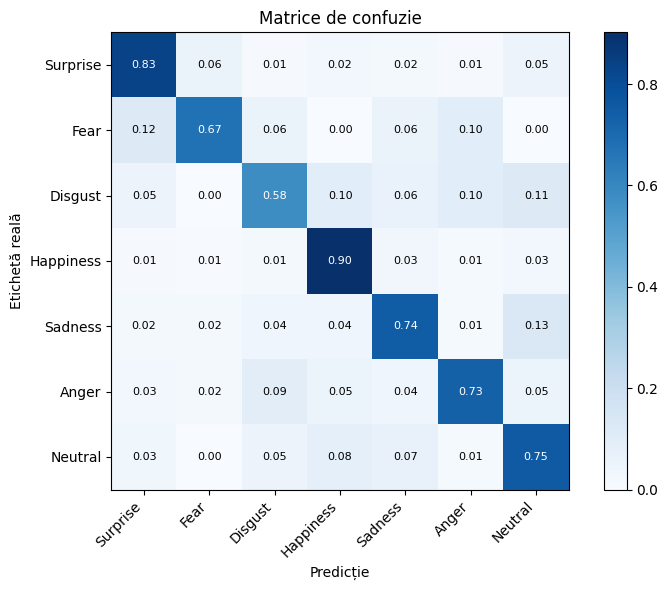

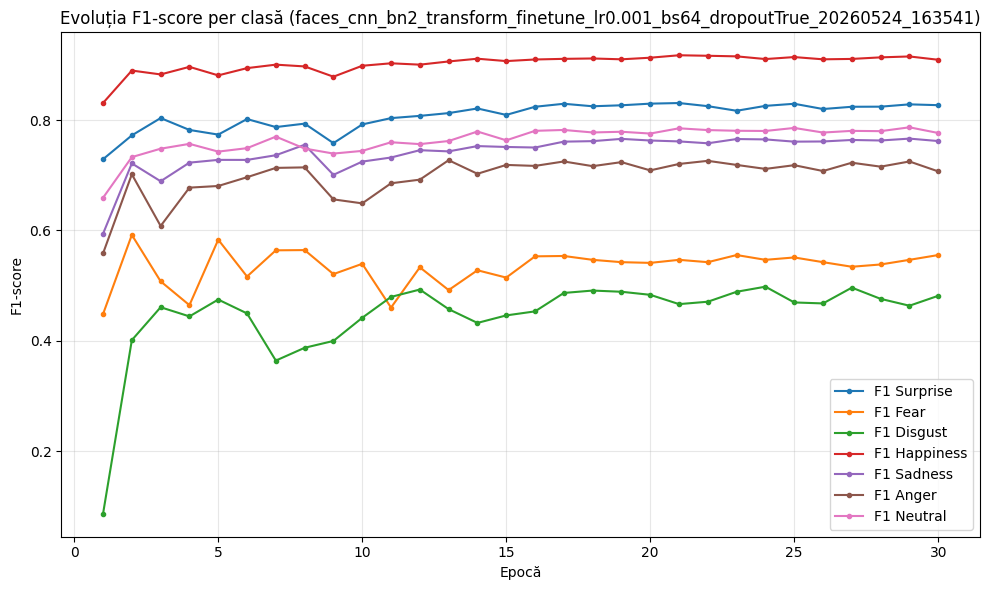

Graficele F1 per clasă salvate în faces_cnn_bn2_transform_finetune_lr0.001_bs64_dropoutTrue_20260524_163541_f1_per_class.png


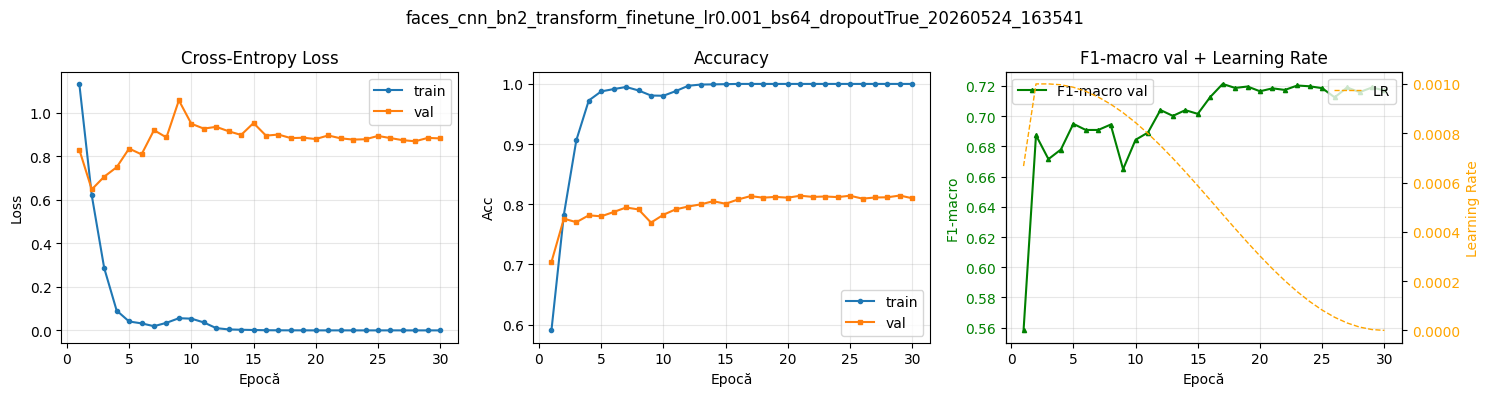

Graficele salvate în faces_cnn_bn2_transform_finetune_lr0.001_bs64_dropoutTrue_20260524_163541_curves.png


In [32]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from torch.optim.lr_scheduler import LambdaLR, CosineAnnealingLR, SequentialLR
import torchvision.models as models

def plot_confusion_matrix(all_labels, all_preds, class_names, title="Matrice de confuzie"):
    """
    Plotează matricea de confuzie normalizată (procente pe rând).
    Normalizarea pe rând arată recall-ul per clasă.
    """
    cm = confusion_matrix(all_labels, all_preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # normalizare pe rând

    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(cm_norm, interpolation="nearest", cmap="Blues")
    plt.colorbar(im, ax=ax)

    ax.set_xticks(range(len(class_names)))
    ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticklabels(class_names)
    ax.set_xlabel("Predicție")
    ax.set_ylabel("Etichetă reală")
    ax.set_title(title)

    # Scriem procentele în celule
    thresh = cm_norm.max() / 2.0
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            ax.text(j, i, f"{cm_norm[i, j]:.2f}",
                    ha="center", va="center",
                    color="white" if cm_norm[i, j] > thresh else "black",
                    fontsize=8)
    plt.tight_layout()
    plt.show()
    return cm

def plot_history(history, run_name="experiment"):
    """
    Afișează 3 grafice:
    1. Curba de Loss (train vs val)
    2. Curba de Accuracy (train vs val)
    3. Curba de F1-macro (val) + Learning Rate

    Cum interpretăm:
    - OVERFITTING: train loss scade continuu, val loss crește → prea multă complexitate
    - UNDERFITTING: ambele curbe sunt ridicate și stagnează → model prea simplu / lr prea mic
    - IDEAL: ambele curbe scad și se apropie
    """
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(run_name, fontsize=12)

    # Grafic 1: Loss
    axes[0].plot(epochs, history["train_loss"], label="train", marker="o", markersize=3)
    axes[0].plot(epochs, history["val_loss"],   label="val",   marker="s", markersize=3)
    axes[0].set_title("Cross-Entropy Loss")
    axes[0].set_xlabel("Epocă")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Grafic 2: Accuracy
    axes[1].plot(epochs, history["train_acc"], label="train", marker="o", markersize=3)
    axes[1].plot(epochs, history["val_acc"],   label="val",   marker="s", markersize=3)
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epocă")
    axes[1].set_ylabel("Acc")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    # Grafic 3: F1-macro + LR
    ax3 = axes[2]
    ax3.plot(epochs, history["val_f1_macro"], color="green", label="F1-macro val",
             marker="^", markersize=3)
    ax3.set_title("F1-macro val + Learning Rate")
    ax3.set_xlabel("Epocă")
    ax3.set_ylabel("F1-macro", color="green")
    ax3.tick_params(axis="y", labelcolor="green")
    ax3.legend(loc="upper left")
    ax3.grid(alpha=0.3)

    if history["lr"]:
        ax3b = ax3.twinx()
        ax3b.plot(epochs, history["lr"], color="orange",
                  linestyle="--", label="LR", linewidth=1)
        ax3b.set_ylabel("Learning Rate", color="orange")
        ax3b.tick_params(axis="y", labelcolor="orange")
        ax3b.legend(loc="upper right")

    plt.tight_layout()
    plt.savefig(f"{run_name}_curves.png", dpi=150)
    plt.show()
    print(f"Graficele salvate în {run_name}_curves.png")

def plot_f1_per_class(history, class_names, run_name="experiment"):
    """
    Plotează evoluția F1-score per clasă pe parcursul antrenării.
    """
    if not history or not history.get("f1_per_class"):
        print("Nu există date de F1 per clasă în istoric.")
        return

    epochs = range(1, len(history["f1_per_class"]) + 1)

    # Convertim lista de array-uri de F1 în array-uri per clasă
    f1_scores_per_class = np.array(history["f1_per_class"]).T # Transpunem

    plt.figure(figsize=(10, 6))
    for i, class_name in enumerate(class_names):
        plt.plot(epochs, f1_scores_per_class[i], label=f"F1 {class_name}", marker='o', markersize=3)

    plt.title(f"Evoluția F1-score per clasă ({run_name})")
    plt.xlabel("Epocă")
    plt.ylabel("F1-score")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{run_name}_f1_per_class.png", dpi=150)
    plt.show()
    print(f"Graficele F1 per clasă salvate în {run_name}_f1_per_class.png")

NUM_EPOCHS = 30
best_val_loss = float("inf")
os.makedirs("checkpoints", exist_ok=True)

# Re-instantiate the ResNet model and its final layer for 7 classes
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
num_classes = 7
in_features = model.fc.in_features
model.fc = nn.Linear(in_features, num_classes)
model = model.to(device)

# Re-define optimizer for the ResNet model with specific learning rates
optimizer = optim.Adam([
    {'params': model.fc.parameters(), 'lr': LR}, # Classification head
    {'params': [p for n, p in model.named_parameters() if 'fc' not in n], 'lr': LR * 0.1} # Backbone (0.1x LR)
], lr=LR, weight_decay=1e-4)

warmup_epochs = 3
# Faza 1: warmup liniar de la 0 -> lr-ul setat in optimizer
warmup = LambdaLR(optimizer, lr_lambda=lambda e: (e + 1) / warmup_epochs)
# Faza 2: cosine decay pana la final
cosine = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS - warmup_epochs)
# SequentialLR il leaga: primele 3 epoci warmup, apoi cosine
scheduler = SequentialLR(optimizer, schedulers=[warmup, cosine], milestones=[warmup_epochs])


# Define FACE_CLASSES here to avoid NameError
FACE_CLASSES = ["Surprise", "Fear", "Disgust", "Happiness", "Sadness", "Anger", "Neutral"]

# ── Numele claselor ───────────────────────────────────────────────────────────
class_names = FACE_CLASSES # Folosim MOLES_CLASSES pentru moles dataset

history = {
    "train_loss": [], "train_acc": [],
    "val_loss":   [], "val_acc":   [],
    "val_f1_macro": [], "val_f1_micro": [],
    "f1_per_class": [],   # ← nou
    "lr": []
}

# ─── Logăm un batch de imagini la pasul 0 ────────────────────────────────────
images, labels = next(iter(train_loader_faces_new))
grid = torchvision.utils.make_grid(images[:16], nrow=4, normalize=True)
writer.add_image("Train/sample_batch", grid, global_step=0)

for epoch in range(NUM_EPOCHS):
    # ── Antrenare ─────────────────────────────────────────────────────────────
    tr_loss, tr_acc = train_one_epoch(model, train_loader_faces_new, criterion, optimizer, device)

    # ── Evaluare ──────────────────────────────────────────────────────────────
    va_loss, va_acc, va_f1_mac, va_f1_mic, all_labels, all_preds = evaluate(
        model, val_loader_faces_new, criterion, device
    )
    scheduler.step() # Corrected: Call without arguments for SequentialLR
    # ── F1 per clasă ──────────────────────────────────────────────────────────
    f1_per_class = f1_score(all_labels, all_preds, average=None, zero_division=0)
    history["f1_per_class"].append(f1_per_class)

    # ── Scheduler ─────────────────────────────────────────────────────────────
    # scheduler.step(va_loss)

    # ── Salvarea celui mai bun model ──────────────────────────────────────────
    if va_loss < best_val_loss:
        best_val_loss = va_loss
        torch.save(model.state_dict(), f"checkpoints/{RUN_NAME}_best.pt")

        # ── Classification report doar când avem best model ───────────────────
        print("\n── Best model! Classification Report ──────────────────────────")
        print(classification_report(all_labels, all_preds,
                                    target_names=class_names, zero_division=0))

    # ── Logging TensorBoard ───────────────────────────────────────────────────
    writer.add_scalar("Loss/train",   tr_loss,   epoch)
    writer.add_scalar("Loss/val",     va_loss,   epoch)
    writer.add_scalar("Acc/train",    tr_acc,    epoch)
    writer.add_scalar("Acc/val",      va_acc,    epoch)
    writer.add_scalar("F1_macro/val", va_f1_mac, epoch)
    writer.add_scalar("F1_micro/val", va_f1_mic, epoch)
    for i, (name, f1) in enumerate(zip(class_names, f1_per_class)):
        writer.add_scalar(f"F1_per_class/{name}", f1, epoch)  # ← grafic separat per clasă
    current_lr = optimizer.param_groups[0]["lr"]
    writer.add_scalar("LR", current_lr, epoch)

    # ── Afișare terminal ──────────────────────────────────────────────────────
    print(f"Epocă {epoch+1:02d}/{NUM_EPOCHS} | "
          f"train loss={tr_loss:.4f} acc={tr_acc:.3f} | "
          f"val loss={va_loss:.4f} acc={va_acc:.3f} "
          f"F1mac={va_f1_mac:.3f} F1mic={va_f1_mic:.3f} "
          f"lr={current_lr:.6f}")
    # F1 per clasă inline
    f1_str = " | ".join(f"{n}={f:.2f}" for n, f in zip(class_names, f1_per_class))
    print(f"  F1/clasă: {f1_str}")

    # ── History ───────────────────────────────────────────────────────────────
    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["val_loss"].append(va_loss)
    history["val_acc"].append(va_acc)
    history["val_f1_macro"].append(va_f1_mac)
    history["val_f1_micro"].append(va_f1_mic)
    history["lr"].append(current_lr)

# ─── Închide TensorBoard ──────────────────────────────────────────────────────
writer.close()
print("Antrenarea s-a terminat!")

# ─── Confusion matrix finală (pe ultimul epoch) ───────────────────────────────
plot_confusion_matrix(all_labels, all_preds, class_names)

# ─── F1 per clasă în timp ─────────────────────────────────────────────────────
plot_f1_per_class(history, class_names, run_name=RUN_NAME)

# ─── Grafice loss/acc/f1 ──────────────────────────────────────────────────────
plot_history(history, run_name=RUN_NAME)